# BreastDCEDL Runnable Pipeline — RTX 3050 4 GB

This notebook performs five explicit stages:

1. environment and file preflight;
2. visible one-time MinCrop extraction;
3. patient-level 75%/10%/15% split and MRI preprocessing;
4. 30-epoch slice-wise segmentation and patient-wise pCR classification;
5. final patient-level Dice and classification accuracy.

Segmentation uses one 2-D slice per GPU step. Classification uses one patient per
step and encodes that patient's selected slices sequentially to reduce peak GPU memory.

> In VS Code choose **Run → Run All**, or click the triangular Run button beside each
> code cell. Merely opening the notebook does not execute Python.


## START HERE

Run the next cell first. It prints the active Python executable and installs only
missing lightweight packages into the selected notebook kernel. It does not reinstall
PyTorch.


In [1]:
import sys
import subprocess
import importlib.util
from pathlib import Path

print('NOTEBOOK STARTED')
print('Python executable:', sys.executable)
print('Python version   :', sys.version.split()[0])
print('Working folder  :', Path.cwd())

if importlib.util.find_spec('torch') is None:
    raise ModuleNotFoundError(
        'PyTorch is not installed in this kernel. Select the BreastDCEDL Python 3.12 '
        'CUDA kernel before continuing.'
    )

required = {
    'nibabel': 'nibabel',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
}
missing = [distribution for module, distribution in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    importlib.invalidate_caches()
else:
    print('Required packages: OK')

print('START CELL PASSED')


NOTEBOOK STARTED
Python executable: c:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe
Python version   : 3.12.10
Working folder  : c:\Users\Asus\AppData\Local\Temp\MicrosoftEdgeDownloads\8b709ed2-9a54-49f4-bb16-07e3e21e29a5
Required packages: OK
START CELL PASSED


## 0. Environment and imports


In [2]:
import os
import re
import json
import math
import time
import random
import hashlib
import tarfile
import tempfile
import warnings
import importlib.util
from pathlib import Path
from dataclasses import dataclass, asdict
from functools import lru_cache
from collections import defaultdict
from contextlib import nullcontext
from typing import Optional, Dict, Any, Tuple, List

missing_packages = [name for name in ('numpy', 'pandas', 'matplotlib', 'nibabel', 'torch', 'sklearn', 'tqdm')
                    if importlib.util.find_spec(name) is None]
if missing_packages:
    raise ModuleNotFoundError(
        'Missing packages in the selected notebook kernel: ' + ', '.join(missing_packages) +
        '. In the activated venv run: pip install nibabel '
        'numpy pandas matplotlib scikit-learn tqdm'
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
)
from tqdm.auto import tqdm

print('Python :', __import__('sys').version.split()[0])
print('PyTorch:', torch.__version__)
print('NiBabel:', nib.__version__)
print('IMPORT CELL PASSED')


Python : 3.12.10
PyTorch: 2.6.0+cu124
NiBabel: 5.4.2
IMPORT CELL PASSED


## 0.1 Configuration tuned for 4 GB VRAM


In [ ]:
@dataclass
class Config:
    seed: int = 1337
    mode: str = 'LOCAL_4GB'        # DEBUG | LOCAL_4GB
    n_channels: int = 5
    channel_names: Tuple[str, ...] = (
        'pre_z', 'early_z', 'late_z', 'early_relative', 'late_relative'
    )
    seg_image_size: int = 192
    roi_image_size: int = 160
    seg_batch_size: int = 1
    cls_batch_size: int = 1
    grad_accum_steps: int = 1       # optimizer update after every sample
    seg_epochs: int = 30
    cls_epochs: int = 30
    seg_lr: float = 1e-3
    cls_lr: float = 3e-4
    weight_decay: float = 1e-4
    num_workers: int = 0           # safest setting on Windows/Jupyter
    train_negative_ratio: float = 1.0
    max_seg_slices_per_patient: int = 24
    bag_slices: int = 10
    roi_padding: int = 12
    clip_low: float = 0.5
    clip_high: float = 99.5
    enhancement_floor_fraction: float = 0.05
    output_clip_z: float = 8.0
    # PHASE 10: development default. `force_full_epochs=True` with
    # `early_stopping_patience=30` used to force every run to the full
    # 30 epochs even when the best checkpoint appeared much earlier. For
    # fast, independent experiments (roadmap PHASE 4-22) we want real
    # early stopping instead. The original locked-baseline values are kept
    # in `BASELINE_CFG_SNAPSHOT` below and are what EXP-00 was trained with.
    early_stopping_patience: int = 7
    force_full_epochs: bool = False
    train_fraction: float = 0.75
    val_fraction: float = 0.10
    test_fraction: float = 0.15
    use_all_train_slices: bool = True
    cache_version: str = 'breastdcedl_75pct_30epoch_v2_torch_resize'


CFG = Config()
if CFG.mode == 'DEBUG':
    CFG.seg_image_size = 96
    CFG.roi_image_size = 96
    CFG.seg_epochs = 1
    CFG.cls_epochs = 1
    CFG.max_seg_slices_per_patient = 4
    CFG.bag_slices = 4

assert CFG.n_channels == len(CFG.channel_names)

# Documented reference only (roadmap PHASE 0 / "one thing I would change
# immediately"): the exact config EXP-00 (baseline/) was frozen with, before
# CFG.force_full_epochs / CFG.early_stopping_patience were changed above.
BASELINE_CFG_SNAPSHOT = {
    'early_stopping_patience': 30,
    'force_full_epochs': True,
    'seg_epochs': 30,
    'cls_epochs': 30,
}

print(json.dumps(asdict(CFG), indent=2))


## 0.2 Reproducibility, CUDA, and mixed precision


In [4]:
def set_seed(seed=CFG.seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
PIN_MEMORY = DEVICE.type == 'cuda'

if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM:', round(props.total_memory / 1024**3, 2), 'GB')
else:
    warnings.warn('CUDA is unavailable. Use CPU only for DEBUG/smoke testing.')


def autocast_context():
    return torch.amp.autocast('cuda', dtype=torch.float16) if USE_AMP else nullcontext()


def make_scaler():
    return torch.amp.GradScaler('cuda', enabled=USE_AMP)


print('DEVICE:', DEVICE, '| AMP:', USE_AMP)


GPU : NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM: 4.0 GB
DEVICE: cuda | AMP: True


## 1. Dataset location and integrity

Place these four required files together:

- `BreastDCEDL_metadata_min_crop.csv`
- `BreastDCEDL_DUKE_min_crop.tar.gz`
- `BreastDCEDL_ISPY1_min_crop.tar.gz`
- `BreastDCEDL_ISPY2_min_crop.tar.gz`

The demo archive, pretrained models, PDF, and older `BreastDCEDL_spy1.zip` are not
required for this pipeline. The default path matches your project layout; edit it if
your files are elsewhere.


In [5]:
import os
from pathlib import Path

# Your exact Windows folders
DEFAULT_DATA_ROOT = Path(r"C:\BreastDCEDL\dataset")
DEFAULT_PROJECT_ROOT = Path(r"C:\BreastDCEDL\CGMRNet")

# Environment variables can optionally override these paths
DATA_ROOT = Path(
    os.environ.get("BREASTDCEDL_ROOT", str(DEFAULT_DATA_ROOT))
).expanduser().resolve()

PROJECT_ROOT = Path(
    os.environ.get("CGMR_PROJECT_ROOT", str(DEFAULT_PROJECT_ROOT))
).expanduser().resolve()

# Dataset and output locations
METADATA_CSV = DATA_ROOT / "BreastDCEDL_metadata_min_crop.csv"
EXTRACTED_ROOT = DATA_ROOT / "extracted_min_crop"

OUTPUT_DIR = PROJECT_ROOT / "outputs_datafirst"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints_datafirst"
CACHE_DIR = PROJECT_ROOT / "cache_datafirst"

# Create required output folders
for folder in (
    EXTRACTED_ROOT,
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    CACHE_DIR,
):
    folder.mkdir(parents=True, exist_ok=True)

# Verify metadata file
DATA_AVAILABLE = METADATA_CSV.is_file()

print("DATA_ROOT    :", DATA_ROOT)
print("PROJECT_ROOT :", PROJECT_ROOT)
print("METADATA_CSV :", METADATA_CSV)
print("Metadata found:", DATA_AVAILABLE)

if not DATA_AVAILABLE:
    raise FileNotFoundError(
        f"\nMetadata CSV was not found:\n{METADATA_CSV}\n\n"
        "Make sure the file is named exactly:\n"
        "BreastDCEDL_metadata_min_crop.csv\n\n"
        "and is located directly inside:\n"
        r"C:\BreastDCEDL\dataset"
    )

print("\nPath configuration successful.")

DATA_ROOT    : C:\BreastDCEDL\dataset
PROJECT_ROOT : C:\BreastDCEDL\CGMRNet
METADATA_CSV : C:\BreastDCEDL\dataset\BreastDCEDL_metadata_min_crop.csv
Metadata found: True

Path configuration successful.


### 1.1 Optional MD5 verification before extraction


In [6]:
EXPECTED_FILES = {
    'BreastDCEDL_metadata_min_crop.csv': 'd58b84d0f343b4b8338cbb222e6dda08',
    'BreastDCEDL_DUKE_min_crop.tar.gz': '16e6c752b9679138e88c188d7a01895f',
    'BreastDCEDL_ISPY1_min_crop.tar.gz': 'd2d2630940a861819e6a385877f45ba5',
    'BreastDCEDL_ISPY2_min_crop.tar.gz': '2f1a00310bd00d344664319fb7bd679c',
}


def file_md5(path: Path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.md5()
    with path.open('rb') as fh:
        while chunk := fh.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def verify_required_files(check_md5=False):
    rows = []
    for name, expected in EXPECTED_FILES.items():
        path = DATA_ROOT / name
        exists = path.is_file()
        actual = file_md5(path) if exists and check_md5 else None
        rows.append({
            'file': name, 'exists': exists,
            'md5_checked': bool(actual),
            'md5_ok': (actual == expected) if actual else None,
            'size_gb': round(path.stat().st_size / 1024**3, 3) if exists else None,
        })
    report = pd.DataFrame(rows)
    display(report)
    if not report['exists'].all():
        raise FileNotFoundError('One or more required MinCrop files are missing.')
    if check_md5 and not report['md5_ok'].all():
        raise IOError('At least one file failed MD5 verification; re-download it.')
    return report


RUN_MD5_CHECK = False  # True reads about 23.5 GB and can take several minutes
file_integrity_report = verify_required_files(check_md5=RUN_MD5_CHECK)


,file,exists,md5_checked,md5_ok,size_gb
0,BreastDCEDL_metadata_min_crop.csv,True,False,None,0.000
1,BreastDCEDL_DUKE_min_crop.tar.gz,True,False,None,8.050
2,BreastDCEDL_ISPY1_min_crop.tar.gz,True,False,None,1.166
3,BreastDCEDL_ISPY2_min_crop.tar.gz,True,False,None,12.698


### 1.2 Safe one-time extraction


In [7]:
def safe_extract_tar(archive_path: Path, destination: Path):
    destination.mkdir(parents=True, exist_ok=True)
    marker = destination / f'.{archive_path.name}.complete'
    if marker.is_file():
        print('Already extracted:', archive_path.name)
        return

    print('\nOpening archive:', archive_path)
    print('Destination    :', destination)
    with tarfile.open(archive_path, 'r:*') as tar:
        members = tar.getmembers()
        total_bytes = sum(member.size for member in members if member.isfile())
        root = destination.resolve()
        for member in members:
            target = (destination / member.name).resolve()
            if target != root and root not in target.parents:
                raise RuntimeError('Unsafe archive member: ' + member.name)

        with tqdm(total=total_bytes, unit='B', unit_scale=True,
                  desc=archive_path.name, leave=True) as progress:
            for member in members:
                tar.extract(member, destination, filter='data')
                if member.isfile():
                    progress.update(member.size)

    marker.touch()
    print('Extraction completed:', archive_path.name)


# Manual extraction is optional. The manifest cell also triggers extraction if needed.
EXTRACT_ARCHIVES_NOW = False
if EXTRACT_ARCHIVES_NOW:
    for archive_name in [name for name in EXPECTED_FILES if name.endswith('.tar.gz')]:
        safe_extract_tar(DATA_ROOT / archive_name, EXTRACTED_ROOT)
else:
    print('Manual extraction skipped; the manifest stage will extract data if necessary.')


Manual extraction skipped; the manifest stage will extract data if necessary.


## 2. Reproducible patient-level 75/10/15 split

The notebook assigns 75% of patients to training, 10% to validation, and 15% to
final testing. Splitting happens at patient level—not slice level—so images from one
patient can never leak across sets. The released split is retained in
`_official_split` for reference but is not used for this requested experiment.


In [8]:
from sklearn.model_selection import train_test_split


REQUIRED_COLUMNS = {
    'pid', 'pCR', 'n_xy', 'n_z', 'n_times', 'pre', 'post_early', 'post_late',
    'mask_start', 'mask_end', 'sraw', 'eraw', 'scol', 'ecol', 'tum_vol',
    'age', 'HR', 'HER2', 'dataset', 'test',
}


def canonical_cohort(value):
    value = re.sub(r'[^a-z0-9]', '', str(value).lower())
    if value in {'spy1', 'ispy1'}:
        return 'ISPY1'
    if value in {'spy2', 'ispy2'}:
        return 'ISPY2'
    if 'duke' in value:
        return 'DUKE'
    return value.upper()


def decode_official_split(series: pd.Series):
    text = series.astype(str).str.strip().str.lower()
    text_map = {
        'train': 'train', 'training': 'train',
        'val': 'val', 'valid': 'val', 'validation': 'val',
        'test': 'test',
    }
    if text.isin(text_map).all():
        return text.map(text_map)
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().all() and set(numeric.astype(int).unique()).issubset({0, 1, 2}):
        return numeric.astype(int).map({0: 'train', 1: 'val', 2: 'test'})
    return pd.Series('unknown', index=series.index)


def candidate_strata(frame):
    pcr = pd.to_numeric(frame['pCR'], errors='coerce').fillna(-1).astype(int).astype(str)
    cohort = frame['_cohort'].fillna('UNKNOWN').astype(str)
    return [cohort + '__pcr_' + pcr, pcr, cohort, None]


def robust_partition(frame, indices, train_size, seed):
    subset = frame.loc[indices]
    last_error = None
    for labels in candidate_strata(subset):
        try:
            left, right = train_test_split(
                np.asarray(indices),
                train_size=train_size,
                random_state=seed,
                shuffle=True,
                stratify=None if labels is None else labels,
            )
            return np.asarray(left), np.asarray(right)
        except ValueError as exc:
            last_error = exc
    raise RuntimeError(f'Unable to create patient split: {last_error}')


def make_patient_split(frame):
    total = CFG.train_fraction + CFG.val_fraction + CFG.test_fraction
    if not np.isclose(total, 1.0):
        raise ValueError(f'Train/validation/test fractions must sum to 1.0, got {total}.')
    if len(frame) < 10:
        raise ValueError('At least 10 patients are required for a 75/10/15 split.')

    all_indices = frame.index.to_numpy()
    train_indices, remaining_indices = robust_partition(
        frame, all_indices, CFG.train_fraction, CFG.seed
    )
    validation_share = CFG.val_fraction / (CFG.val_fraction + CFG.test_fraction)
    val_indices, test_indices = robust_partition(
        frame, remaining_indices, validation_share, CFG.seed + 1
    )

    split = pd.Series(index=frame.index, dtype='object')
    split.loc[train_indices] = 'train'
    split.loc[val_indices] = 'val'
    split.loc[test_indices] = 'test'
    if split.isna().any():
        raise RuntimeError('Some patients were not assigned to a split.')
    return split


metadata = pd.read_csv(METADATA_CSV, dtype={'pid': str})
metadata['pid'] = metadata['pid'].str.strip()
missing_columns = sorted(REQUIRED_COLUMNS - set(metadata.columns))
if missing_columns:
    raise ValueError('Missing metadata columns: ' + ', '.join(missing_columns))
if metadata['pid'].isna().any() or metadata['pid'].duplicated().any():
    raise ValueError('Patient IDs must be present and unique.')

for target in ('pCR', 'HR', 'HER2'):
    values = pd.to_numeric(metadata[target], errors='coerce').dropna()
    invalid = set(values.unique()) - {0, 1}
    if invalid:
        raise ValueError(f'{target} has non-binary values: {sorted(invalid)}')

metadata['_cohort'] = metadata['dataset'].map(canonical_cohort)
metadata['_official_split'] = decode_official_split(metadata['test'])
metadata['_split'] = make_patient_split(metadata)

assert metadata.groupby('pid')['_split'].nunique().max() == 1
assert set(metadata['_split']) == {'train', 'val', 'test'}

split_audit = metadata.groupby('_split').agg(
    patients=('pid', 'nunique'),
    pcr_available=('pCR', 'count'),
    pcr_positive=('pCR', lambda s: int(pd.to_numeric(s, errors='coerce').fillna(0).sum())),
).reindex(['train', 'val', 'test'])
split_audit['fraction'] = split_audit['patients'] / split_audit['patients'].sum()
split_audit['pcr_positive_rate'] = (
    split_audit['pcr_positive'] / split_audit['pcr_available'].replace(0, np.nan)
)

display(split_audit)
display(pd.crosstab(metadata['_cohort'], metadata['_split'], margins=True))
split_audit.to_csv(OUTPUT_DIR / 'patient_split_75_10_15_audit.csv')
metadata[['pid', '_cohort', '_official_split', '_split', 'pCR']].to_csv(
    OUTPUT_DIR / 'patient_split_assignments.csv', index=False
)
print('Patient-level split and leakage check: PASSED')
print('Requested training fraction:', CFG.train_fraction)


,patients,pcr_available,pcr_positive,fraction,pcr_positive_rate
_split,,,,,
train,1552,1088,321,0.749758,0.295037
val,207,146,43,0.100000,0.294521
test,311,218,64,0.150242,0.293578


_split,test,train,val,All
_cohort,,,,
DUKE,138,687,91,916
ISPY1,26,129,17,172
ISPY2,147,736,99,982
All,311,1552,207,2070


Patient-level split and leakage check: PASSED
Requested training fraction: 0.75


## 3. NIfTI discovery and patient manifest


In [9]:
print('MANIFEST STAGE STARTED')
AUTO_EXTRACT_IF_NIFTI_MISSING = True

MINCROP_ARCHIVES = (
    "BreastDCEDL_DUKE_min_crop.tar.gz",
    "BreastDCEDL_ISPY1_min_crop.tar.gz",
    "BreastDCEDL_ISPY2_min_crop.tar.gz",
)


def natural_key(value):
    return [
        int(x) if x.isdigit() else x.lower()
        for x in re.split(r"(\d+)", str(value))
    ]


def normalized_text(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def is_mask_file(path: Path):
    name = normalized_text(path.name)
    mask_tokens = (
        "mask",
        "segmentation",
        "segm",
        "label",
        "annotation",
    )
    return any(token in name for token in mask_tokens)


@lru_cache(maxsize=512)
def nifti_header(path_text: str):
    image = nib.load(path_text, mmap=True)
    return tuple(image.shape), np.asarray(image.affine, dtype=np.float64)


def discover_nifti_files():
    search_roots = [
        EXTRACTED_ROOT.resolve(),
        DATA_ROOT.resolve(),
    ]

    found = set()

    for root in search_roots:
        if not root.exists():
            continue

        found.update(
            path.resolve()
            for path in root.rglob("*.nii")
            if path.is_file()
        )

        found.update(
            path.resolve()
            for path in root.rglob("*.nii.gz")
            if path.is_file()
        )

    return sorted(found, key=natural_key)


def locate_archive(archive_name):
    # First check the expected direct location
    direct_path = DATA_ROOT / archive_name

    if direct_path.is_file():
        return direct_path.resolve()

    # Then search subdirectories
    matches = [
        path.resolve()
        for path in DATA_ROOT.rglob(archive_name)
        if path.is_file()
    ]

    return matches[0] if matches else None


def ensure_nifti_files():
    files = discover_nifti_files()

    if files:
        print(
            f"Found {len(files):,} existing NIfTI files. "
            "Extraction will not be repeated."
        )
        return files

    archive_paths = {
        archive_name: locate_archive(archive_name)
        for archive_name in MINCROP_ARCHIVES
    }

    missing_archives = [
        archive_name
        for archive_name, archive_path in archive_paths.items()
        if archive_path is None
    ]

    if missing_archives:
        expected_paths = "\n".join(
            f"  - {DATA_ROOT / archive_name}"
            for archive_name in missing_archives
        )

        raise FileNotFoundError(
            "No extracted NIfTI files were found, and the following "
            f"archives are missing:\n\n{expected_paths}\n\n"
            f"Place all three archives inside:\n{DATA_ROOT}"
        )

    print("\nMinCrop archives found:")

    for archive_name, archive_path in archive_paths.items():
        print(f"  {archive_name}")
        print(f"    {archive_path}")

    if not AUTO_EXTRACT_IF_NIFTI_MISSING:
        raise RuntimeError(
            "\nThe archives exist, but no extracted NIfTI files were found.\n"
            "Set AUTO_EXTRACT_IF_NIFTI_MISSING = True and rerun this cell."
        )

    print("\nNo extracted NIfTI files were found.")
    print("Starting one-time archive extraction.")
    print("This can take a long time. Do not interrupt the kernel.\n")

    EXTRACTED_ROOT.mkdir(parents=True, exist_ok=True)

    for archive_path in archive_paths.values():
        safe_extract_tar(
            archive_path=archive_path,
            destination=EXTRACTED_ROOT,
        )

    files = discover_nifti_files()

    if not files:
        raise RuntimeError(
            "Archive extraction completed, but no .nii or .nii.gz "
            f"files were found under:\n{EXTRACTED_ROOT}\n\n"
            "Inspect the extracted folder structure."
        )

    print(f"\nExtraction verified: {len(files):,} NIfTI files found.")

    return files


def select_phase_files(row, patient_files):
    masks = sorted(
        [path for path in patient_files if is_mask_file(path)],
        key=natural_key,
    )

    images = sorted(
        [path for path in patient_files if not is_mask_file(path)],
        key=natural_key,
    )

    result = {
        "pre_path": None,
        "early_path": None,
        "late_path": None,
        "pre_frame": None,
        "early_frame": None,
        "late_frame": None,
        "mask_path": str(masks[0]) if masks else None,
    }

    if not images:
        return result

    indices = {
        "pre": int(float(row["pre"])),
        "early": int(float(row["post_early"])),
        "late": int(float(row["post_late"])),
    }

    # Find a usable 4-D DCE volume
    four_d_candidates = []

    for path in images:
        try:
            shape, _ = nifti_header(str(path))
        except (OSError, ValueError):
            continue

        if len(shape) == 4 and max(indices.values()) < shape[3]:
            spatial_size = int(np.prod(shape[:3]))
            four_d_candidates.append((spatial_size, path))

    if four_d_candidates:
        _, dce_path = max(
            four_d_candidates,
            key=lambda item: item[0],
        )

        for phase, frame in indices.items():
            result[f"{phase}_path"] = str(dce_path)
            result[f"{phase}_frame"] = frame

        return result

    # Otherwise search separate 3-D phase files
    phase_patterns = {
        "pre": (
            "precontrast",
            "pre",
            "phase0",
            "time0",
        ),
        "early": (
            "postearly",
            "earlypost",
            "early",
        ),
        "late": (
            "postlate",
            "latepost",
            "late",
        ),
    }

    explicit_files = {}

    for phase, tokens in phase_patterns.items():
        explicit_files[phase] = next(
            (
                path
                for path in images
                if any(
                    token in normalized_text(path.name)
                    for token in tokens
                )
            ),
            None,
        )

    if all(explicit_files.values()):
        for phase, path in explicit_files.items():
            result[f"{phase}_path"] = str(path)

        return result

    # Final fallback: use metadata phase indices
    if max(indices.values()) < len(images):
        for phase, index in indices.items():
            result[f"{phase}_path"] = str(images[index])

    return result


def build_manifest(metadata_frame):
    files = ensure_nifti_files()

    pid_pairs = sorted(
        [
            (normalized_text(pid), str(pid))
            for pid in metadata_frame["pid"]
        ],
        key=lambda pair: len(pair[0]),
        reverse=True,
    )

    grouped_files = {
        str(pid): []
        for pid in metadata_frame["pid"]
    }

    unmatched_files = []

    for path in files:
        path_text = normalized_text(str(path))

        candidates = [
            (pid_token, original_pid)
            for pid_token, original_pid in pid_pairs
            if pid_token and pid_token in path_text
        ]

        matched_pid = candidates[0][1] if candidates else None

        # Avoid ambiguous matches
        if (
            len(candidates) > 1
            and len(candidates[0][0]) == len(candidates[1][0])
        ):
            matched_pid = None

        if matched_pid is None:
            unmatched_files.append(path)
        else:
            grouped_files[matched_pid].append(path)

    manifest_rows = []

    for _, row in metadata_frame.iterrows():
        patient_id = str(row["pid"])
        patient_files = grouped_files.get(patient_id, [])

        selected_files = select_phase_files(
            row=row,
            patient_files=patient_files,
        )

        manifest_rows.append({
            **row.to_dict(),
            **selected_files,
            "n_discovered_files": len(patient_files),
        })

    frame = pd.DataFrame(manifest_rows)

    frame["phase_ready"] = (
        frame[["pre_path", "early_path", "late_path"]]
        .notna()
        .all(axis=1)
    )

    frame["dense_mask_ready"] = (
        frame["mask_path"].notna()
        & frame["_cohort"].isin(["ISPY1", "ISPY2"])
    )

    manifest_path = OUTPUT_DIR / "patient_manifest.csv"
    frame.to_csv(manifest_path, index=False)

    print("\nManifest summary")
    print("----------------")
    print("NIfTI files:", len(files))
    print("Unmatched files:", len(unmatched_files))
    print(
        "Patients with three usable phases:",
        int(frame["phase_ready"].sum()),
        "/",
        len(frame),
    )
    print(
        "Patients with dense masks:",
        int(frame["dense_mask_ready"].sum()),
    )
    print("Manifest saved:", manifest_path)

    display(
        pd.crosstab(
            frame["_cohort"],
            frame["phase_ready"],
            margins=True,
        )
    )

    return frame


manifest = build_manifest(metadata)

if not manifest["phase_ready"].any():
    raise RuntimeError(
        "Manifest contains no usable patients. "
        "Inspect the extracted folder layout and patient filenames."
    )


MANIFEST STAGE STARTED
Found 7,891 existing NIfTI files. Extraction will not be repeated.

Manifest summary
----------------
NIfTI files: 7891
Unmatched files: 12
Patients with three usable phases: 175 / 2070
Patients with dense masks: 1154
Manifest saved: C:\BreastDCEDL\CGMRNet\outputs_datafirst\patient_manifest.csv


phase_ready,False,True,All
_cohort,,,
DUKE,913,3,916
ISPY1,0,172,172
ISPY2,982,0,982
All,1895,175,2070


## 3.1 PHASE 1 — Classification eligibility audit

The overall 75/10/15 patient split above already covers every patient with a
readable metadata row (2,070 patients), not only the ones usable for
classification. Metadata reports pCR for 1,452 of them (1,088 train / 146
val / 218 test), yet the old `classification_frame` filter
(`manifest['phase_ready'] & pCR.notna()`) kept far fewer. Before assuming
"only a couple hundred patients have labels", audit exactly where the rest
are lost: missing pre/early/late phase files, no dense tumour mask, or no
usable ROI (`scol`/`ecol`/`sraw`/`eraw`/`n_xy`). A patient can fail several
of these at once, so reasons are tracked as a set, not a single label.


In [ ]:
def valid_pre(row):
    return pd.notna(row.get('pre_path'))


def valid_early(row):
    return pd.notna(row.get('early_path'))


def valid_late(row):
    return pd.notna(row.get('late_path'))


def valid_mask(row):
    return pd.notna(row.get('mask_path'))


def valid_roi(row):
    values = pd.to_numeric(
        pd.Series([row.get(c) for c in ('n_xy', 'scol', 'ecol', 'sraw', 'eraw')]),
        errors='coerce',
    )
    if values.isna().any():
        return False
    n_xy, scol, ecol, sraw, eraw = values.tolist()
    return n_xy > 0 and ecol > scol and eraw > sraw


audit_rows = []

for _, row in manifest.iterrows():
    reasons = []

    pcr_value = pd.to_numeric(pd.Series([row.get('pCR')]), errors='coerce').iloc[0]
    if pd.isna(pcr_value):
        reasons.append('missing_pcr')
    if not valid_pre(row):
        reasons.append('missing_pre')
    if not valid_early(row):
        reasons.append('missing_early')
    if not valid_late(row):
        reasons.append('missing_late')
    if not valid_mask(row):
        reasons.append('missing_mask')
    if not valid_roi(row):
        reasons.append('missing_roi')

    audit_rows.append({
        'pid': row['pid'],
        'cohort': row['_cohort'],
        'split': row['_split'],
        'pCR': pcr_value,
        'eligible': len(reasons) == 0,
        'primary_reason': reasons[0] if reasons else 'none',
        'reasons': '|'.join(reasons),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(OUTPUT_DIR / 'classification_eligibility_audit.csv', index=False)

print('Eligible for the FULL pipeline (all six checks, incl. dense mask):')
print(audit_df['eligible'].value_counts())
print()

print('Reason counts (NOT mutually exclusive -- a patient can hit several):')
for reason in (
    'missing_pcr', 'missing_pre', 'missing_early',
    'missing_late', 'missing_mask', 'missing_roi',
):
    count = int(audit_df['reasons'].str.contains(reason).sum())
    print(f'  {reason:15s} {count}')
print()

print('Primary exclusion reason (first check failed, in the order above):')
print(audit_df.loc[~audit_df['eligible'], 'primary_reason'].value_counts())
print()

# The current classifier crops the metadata ROI directly -- it never touches
# the dense tumour mask -- so a patient missing only `missing_mask` is still
# usable for classification (PHASE 18's segmentation-based ROI is a later,
# separate experiment). Track that looser flag explicitly.
audit_df['classification_eligible'] = ~audit_df['reasons'].str.contains(
    'missing_pcr|missing_pre|missing_early|missing_late|missing_roi'
)
print('Classification-eligible (dense mask NOT required):',
      int(audit_df['classification_eligible'].sum()), '/', len(audit_df))
display(pd.crosstab(audit_df['cohort'], audit_df['classification_eligible'], margins=True))


## 3.2 PHASE 2 — Verify the stratified split on the eligible cohort

The patient split (`make_patient_split` / `candidate_strata`, above) already
splits at the patient level and already tries to stratify by
`cohort + pCR` before falling back to `pCR` alone -- so it is **not**
replaced here. What still needs checking is whether that stratification
survives once the classification-eligibility filter above shrinks 2,070
patients down to the eligible cohort: a global stratified split does not
guarantee balanced pCR ratios inside an arbitrary subset of it.


In [ ]:
eligible_pids = set(audit_df.loc[audit_df['classification_eligible'], 'pid'])

eligible_view = manifest[manifest['pid'].isin(eligible_pids)].copy()
eligible_view['pCR'] = pd.to_numeric(eligible_view['pCR'], errors='coerce').astype(int)

split_pcr_counts = eligible_view.groupby(['_split', 'pCR']).size().unstack(fill_value=0)
split_pcr_counts = split_pcr_counts.reindex(['train', 'val', 'test'])
split_pcr_counts.loc['total'] = split_pcr_counts.sum()
display(split_pcr_counts)

pcr_rate = eligible_view.groupby('_split')['pCR'].mean().reindex(['train', 'val', 'test'])
print('pCR positive rate per split (eligible cohort only):')
print(pcr_rate.round(3))


## 4. MRI preprocessing

Each slice becomes five channels:

1. robustly normalised pre-contrast;
2. robustly normalised early post-contrast;
3. robustly normalised late post-contrast;
4. relative early enhancement `(early − pre) / |pre|`;
5. relative late enhancement `(late − pre) / |pre|`.

All statistics are calculated inside a shared tissue foreground mask. The background
is reset to exactly zero. MinCrop is already tumour-centred at 256×256, so N4,
registration and resampling are not applied automatically.


In [10]:
@lru_cache(maxsize=128)
def open_nifti(path_text: str):
    return nib.load(path_text, mmap=True)


def load_slice(path, z, frame=None):
    image = open_nifti(str(path))
    shape = image.shape
    z = int(z)
    if not 0 <= z < shape[2]:
        raise IndexError(f'z={z} is outside {shape} for {path}')
    if len(shape) == 4:
        if frame is None or pd.isna(frame):
            raise ValueError(f'Frame is required for 4-D NIfTI: {path}')
        array = np.asarray(image.dataobj[:, :, z, int(frame)])
    elif len(shape) == 3:
        array = np.asarray(image.dataobj[:, :, z])
    else:
        raise ValueError(f'Unsupported NIfTI shape {shape}: {path}')
    return np.nan_to_num(array.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)


def tissue_mask(*phases):
    return np.logical_or.reduce([np.isfinite(x) & (np.abs(x) > 1e-6) for x in phases])


def robust_clip(array, mask):
    values = array[mask]
    if values.size < 16:
        return array
    low, high = np.percentile(values, [CFG.clip_low, CFG.clip_high])
    if not np.isfinite([low, high]).all() or high <= low:
        return array
    return np.clip(array, low, high)


def foreground_zscore(array, mask):
    array = robust_clip(array, mask)
    values = array[mask]
    output = np.zeros_like(array, dtype=np.float32)
    if values.size < 16:
        return output
    mean, std = float(values.mean()), float(values.std())
    if not np.isfinite(std) or std < 1e-6:
        return output
    output[mask] = (array[mask] - mean) / std
    return np.clip(output, -CFG.output_clip_z, CFG.output_clip_z).astype(np.float32)


def relative_enhancement(post, pre, mask):
    baseline = np.abs(pre[mask])
    scale = float(np.median(baseline)) if baseline.size else 1.0
    floor = max(scale * CFG.enhancement_floor_fraction, 1e-3)
    output = np.zeros_like(pre, dtype=np.float32)
    output[mask] = (post[mask] - pre[mask]) / np.maximum(np.abs(pre[mask]), floor)
    return foreground_zscore(output, mask)


def preprocess_phases(pre, early, late):
    pre, early, late = [
        np.nan_to_num(np.asarray(x, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
        for x in (pre, early, late)
    ]
    if not (pre.shape == early.shape == late.shape):
        raise ValueError(f'Phase shapes differ: {pre.shape}, {early.shape}, {late.shape}')
    mask = tissue_mask(pre, early, late)
    if int(mask.sum()) < 16:
        return np.zeros((CFG.n_channels, *pre.shape), dtype=np.float32)
    channels = np.stack([
        foreground_zscore(pre, mask),
        foreground_zscore(early, mask),
        foreground_zscore(late, mask),
        relative_enhancement(early, pre, mask),
        relative_enhancement(late, pre, mask),
    ]).astype(np.float32)
    channels[:, ~mask] = 0.0
    if not np.isfinite(channels).all():
        raise FloatingPointError('Non-finite value remained after preprocessing.')
    return np.ascontiguousarray(channels)


def resize_channels(channels, size):
    """Resize CxHxW channels using PyTorch; OpenCV is not required."""
    array = np.ascontiguousarray(channels, dtype=np.float32)
    if array.ndim != 3:
        raise ValueError(f'Expected channels with shape CxHxW, received {array.shape}.')
    tensor = torch.from_numpy(array).unsqueeze(0)
    resized = F.interpolate(
        tensor, size=(int(size), int(size)), mode='bilinear', align_corners=False
    )
    output = resized.squeeze(0).numpy().astype(np.float32, copy=False)
    return np.ascontiguousarray(output)


def resize_mask(mask, size):
    """Resize a binary HxW mask with nearest-neighbour interpolation."""
    array = np.ascontiguousarray(mask, dtype=np.float32)
    if array.ndim != 2:
        raise ValueError(f'Expected a 2-D mask, received {array.shape}.')
    tensor = torch.from_numpy(array).unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(tensor, size=(int(size), int(size)), mode='nearest')
    output = resized[0, 0].numpy().astype(np.float32, copy=False)
    return np.ascontiguousarray((output >= 0.5).astype(np.float32))


PREPROCESS_FINGERPRINT = hashlib.sha256(
    json.dumps({
        'version': CFG.cache_version, 'channels': CFG.channel_names,
        'clip': [CFG.clip_low, CFG.clip_high],
        'floor': CFG.enhancement_floor_fraction,
        'seg_size': CFG.seg_image_size, 'roi_size': CFG.roi_image_size,
    }, sort_keys=True).encode()
).hexdigest()[:12]
print('Resize backend: torch.nn.functional.interpolate')
print('Preprocessing fingerprint:', PREPROCESS_FINGERPRINT)


Resize backend: torch.nn.functional.interpolate
Preprocessing fingerprint: 253d9002c3cb


### 4.1 Preprocessing quality-control gate


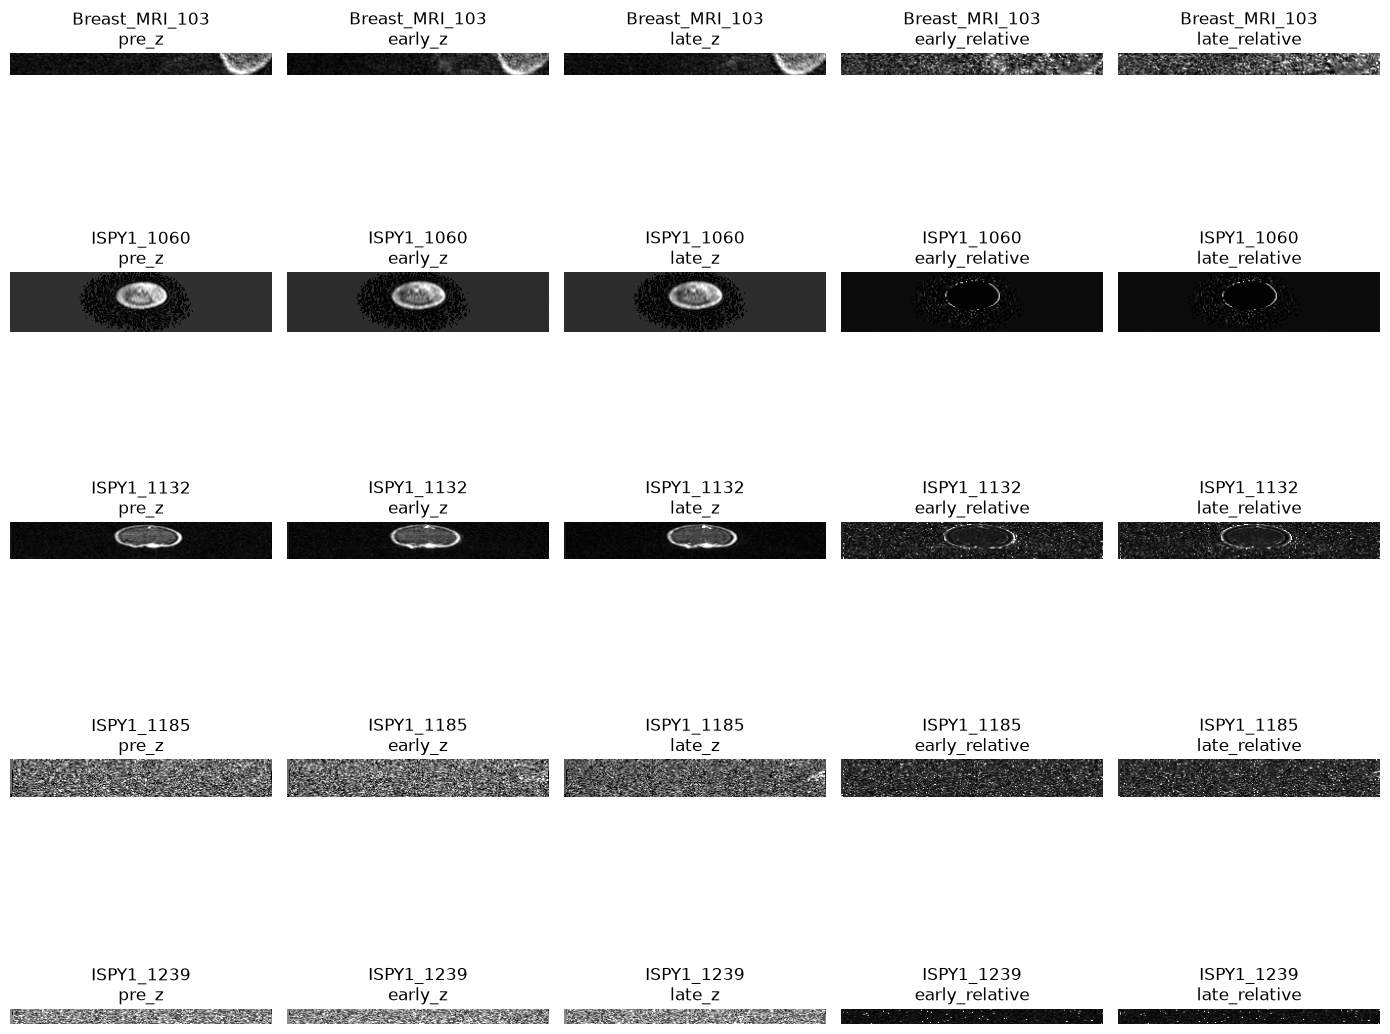

Preprocessing QC PASSED -> C:\BreastDCEDL\CGMRNet\outputs_datafirst\preprocessing_qc_253d9002c3cb.png


In [11]:
def preprocessing_qc(manifest_frame, n_samples=5):
    sample_frame = manifest_frame[(manifest_frame['_split'] == 'train') & manifest_frame['phase_ready']]
    if sample_frame.empty:
        raise RuntimeError('No training patients are available for QC.')
    sample_frame = sample_frame.sort_values(['_cohort', 'pid'])
    positions = np.linspace(0, len(sample_frame) - 1, min(n_samples, len(sample_frame))).round().astype(int)
    records, images = [], []
    for position in positions:
        row = sample_frame.iloc[int(position)]
        shape, _ = nifti_header(str(row['pre_path']))
        start = int(np.clip(float(row['mask_start']), 0, shape[2] - 1))
        end = int(np.clip(float(row['mask_end']), start, shape[2] - 1))
        z = (start + end) // 2
        pre = load_slice(row['pre_path'], z, row.get('pre_frame'))
        early = load_slice(row['early_path'], z, row.get('early_frame'))
        late = load_slice(row['late_path'], z, row.get('late_frame'))
        processed = preprocess_phases(pre, early, late)
        foreground = np.any(np.abs(processed[:3]) > 1e-6, axis=0)
        record = {
            'pid': str(row['pid']), 'cohort': row['_cohort'], 'z': z,
            'shape': list(processed.shape), 'finite': bool(np.isfinite(processed).all()),
            'foreground_fraction': float(foreground.mean()),
            'channel_means': processed[:, foreground].mean(1).round(4).tolist(),
            'channel_stds': processed[:, foreground].std(1).round(4).tolist(),
        }
        if not record['finite'] or processed.shape[0] != CFG.n_channels:
            raise RuntimeError('QC failure: ' + json.dumps(record))
        records.append(record); images.append(processed)

    fig, axes = plt.subplots(len(images), CFG.n_channels, figsize=(14, 2.6 * len(images)), squeeze=False)
    for r, image in enumerate(images):
        for c, name in enumerate(CFG.channel_names):
            axes[r, c].imshow(image[c], cmap='gray')
            axes[r, c].set_title(f'{records[r]["pid"]}\n{name}')
            axes[r, c].axis('off')
    fig.tight_layout()
    panel_path = OUTPUT_DIR / f'preprocessing_qc_{PREPROCESS_FINGERPRINT}.png'
    fig.savefig(panel_path, dpi=160, bbox_inches='tight')
    plt.show()
    report = {'status': 'passed', 'fingerprint': PREPROCESS_FINGERPRINT, 'samples': records}
    (OUTPUT_DIR / f'preprocessing_qc_{PREPROCESS_FINGERPRINT}.json').write_text(
        json.dumps(report, indent=2), encoding='utf-8')
    print('Preprocessing QC PASSED ->', panel_path)
    return report


RUN_PREPROCESSING_QC = True
qc_report = preprocessing_qc(manifest) if RUN_PREPROCESSING_QC else None
if not RUN_PREPROCESSING_QC:
    print('Set RUN_PREPROCESSING_QC=True and run this cell before training.')


### 4.2 Lesion-preserving paired augmentation


In [12]:
class PairedAugment:
    def __init__(self, train=True, crop_scale=(0.90, 1.0), hflip_probability=0.5):
        self.train = train
        self.crop_scale = crop_scale
        self.hflip_probability = hflip_probability

    @staticmethod
    def lesion_window(mask, h, w, crop_h, crop_w):
        if mask is None or not torch.any(mask > 0):
            top = int(torch.randint(0, h - crop_h + 1, (1,)))
            left = int(torch.randint(0, w - crop_w + 1, (1,)))
            return top, left, crop_h, crop_w
        yy, xx = torch.where(mask[0] > 0)
        y0, y1 = int(yy.min()), int(yy.max()) + 1
        x0, x1 = int(xx.min()), int(xx.max()) + 1
        crop_h, crop_w = min(h, max(crop_h, y1-y0)), min(w, max(crop_w, x1-x0))
        top_lo, top_hi = max(0, y1-crop_h), min(y0, h-crop_h)
        left_lo, left_hi = max(0, x1-crop_w), min(x0, w-crop_w)
        top = top_lo if top_hi <= top_lo else int(torch.randint(top_lo, top_hi+1, (1,)))
        left = left_lo if left_hi <= left_lo else int(torch.randint(left_lo, left_hi+1, (1,)))
        return top, left, crop_h, crop_w

    def __call__(self, image, mask=None):
        image = image.float()
        mask = None if mask is None else mask.float().clamp(0, 1)
        if not self.train:
            return image.contiguous(), None if mask is None else mask.contiguous()
        if torch.rand(()) < self.hflip_probability:
            image = torch.flip(image, (-1,))
            mask = None if mask is None else torch.flip(mask, (-1,))
        h, w = image.shape[-2:]
        scale = float(torch.empty(1).uniform_(*self.crop_scale))
        crop_h, crop_w = max(16, round(h*scale)), max(16, round(w*scale))
        top, left, crop_h, crop_w = self.lesion_window(mask, h, w, crop_h, crop_w)
        image = F.interpolate(image[None, :, top:top+crop_h, left:left+crop_w],
                              size=(h, w), mode='bilinear', align_corners=False)[0]
        if mask is not None:
            mask = F.interpolate(mask[None, :, top:top+crop_h, left:left+crop_w],
                                 size=(h, w), mode='nearest')[0]
        gain = float(torch.empty(1).uniform_(0.93, 1.07))
        bias = float(torch.empty(1).uniform_(-0.04, 0.04))
        image = image * gain
        image[:3] += bias
        image += torch.randn_like(image) * 0.01
        return image.clamp(-8, 8).contiguous(), None if mask is None else mask.contiguous()


train_augment = PairedAugment(train=True)
eval_augment = PairedAugment(train=False)


## 5. Segmentation dataset: all training slices, one at a time

Every slice from the densely annotated patients assigned to the 75% training split is
used. Validation and test also include every slice. With `seg_batch_size=1`, the GPU
receives exactly one 2-D slice per step. DUKE patients without dense masks can be used
for classification but cannot supervise segmentation Dice training.


In [13]:
def mask_volume(path):
    image = open_nifti(str(path))
    array = np.asarray(image.dataobj)
    if array.ndim == 4: array = array[..., 0]
    if array.ndim != 3: raise ValueError(f'Mask must be 3-D: {path}')
    return np.isfinite(array) & (array > 0)


def deterministic_limit(values, maximum):
    values = sorted(set(map(int, values)))
    if maximum is None or len(values) <= maximum: return values
    positions = np.linspace(0, len(values)-1, maximum).round().astype(int)
    return [values[i] for i in positions]


def build_segmentation_index(manifest_frame):
    rows = []
    dense = manifest_frame[manifest_frame['phase_ready'] & manifest_frame['dense_mask_ready']]
    if CFG.mode == 'DEBUG':
        dense = dense.groupby('_split', group_keys=False).head(4)
    rng = np.random.default_rng(CFG.seed)
    for _, row in tqdm(dense.iterrows(), total=len(dense), desc='Segmentation index'):
        try:
            mask = mask_volume(row['mask_path'])
            phase_shape, _ = nifti_header(str(row['pre_path']))
            if mask.shape != tuple(phase_shape[:3]):
                warnings.warn(f'Mask/phase shape mismatch for {row["pid"]}; skipped.')
                continue
            positive = np.where(np.any(mask, axis=(0, 1)))[0].astype(int).tolist()
            if not positive: continue
            all_slices = np.arange(mask.shape[2], dtype=int)
            if row['_split'] == 'train' and not CFG.use_all_train_slices:
                negative = np.setdiff1d(all_slices, positive)
                selected_positive = deterministic_limit(
                    positive, CFG.max_seg_slices_per_patient)
                remaining = max(CFG.max_seg_slices_per_patient-len(selected_positive), 0)
                requested_negative = max(1, round(len(selected_positive)*CFG.train_negative_ratio))
                n_negative = min(len(negative), remaining, requested_negative)
                selected_negative = (rng.choice(negative, n_negative, replace=False).tolist()
                                     if n_negative else [])
                selected = sorted(selected_positive + selected_negative)
            else:
                # Requested full-data mode: every slice from each eligible patient.
                selected = all_slices.tolist()
            for z in selected:
                rows.append({**row.to_dict(), 'slice_idx': int(z),
                             'tumour_present': int(z in set(positive))})
        except Exception as exc:
            warnings.warn(f'Skipping segmentation patient {row["pid"]}: {exc}')
    index = pd.DataFrame(rows)
    if index.empty: raise RuntimeError('No dense segmentation slices were indexed.')
    index.to_csv(OUTPUT_DIR / 'segmentation_index.csv', index=False)
    display(index.groupby(['_split', 'tumour_present']).size().unstack(fill_value=0))
    return index


seg_index = build_segmentation_index(manifest)


Segmentation index:   0%|          | 0/172 [00:00<?, ?it/s]

tumour_present,0,1
_split,,
test,4796,1860
train,22002,11022
val,2717,1635


In [14]:
class SegmentationSliceDataset(Dataset):
    def __init__(self, frame, train=False):
        self.frame = frame.reset_index(drop=True)
        self.transform = train_augment if train else eval_augment

    def __len__(self): return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        z = int(row['slice_idx'])
        pre = load_slice(row['pre_path'], z, row.get('pre_frame'))
        early = load_slice(row['early_path'], z, row.get('early_frame'))
        late = load_slice(row['late_path'], z, row.get('late_frame'))
        image = resize_channels(preprocess_phases(pre, early, late), CFG.seg_image_size)
        mask = resize_mask(load_slice(row['mask_path'], z) > 0, CFG.seg_image_size)
        image_t = torch.from_numpy(image)
        mask_t = torch.from_numpy(mask[None])
        image_t, mask_t = self.transform(image_t, mask_t)
        return {'image': image_t, 'mask': mask_t,
                'pid': str(row['pid']), 'slice_idx': z}


def seed_worker(worker_id):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed); random.seed(worker_seed)


def make_loader(dataset, batch_size, shuffle):
    kwargs = dict(
        dataset=dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=CFG.num_workers, pin_memory=PIN_MEMORY,
        persistent_workers=CFG.num_workers > 0, worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(CFG.seed),
    )
    if CFG.num_workers > 0: kwargs['prefetch_factor'] = 2
    return DataLoader(**kwargs)


seg_frames = {split: seg_index[seg_index['_split'] == split].copy()
              for split in ('train', 'val', 'test')}
seg_datasets = {split: SegmentationSliceDataset(frame, train=(split == 'train'))
                for split, frame in seg_frames.items()}
seg_loaders = {split: make_loader(dataset, CFG.seg_batch_size, shuffle=(split == 'train'))
               for split, dataset in seg_datasets.items()}
print('Segmentation slices:', {split: len(dataset) for split, dataset in seg_datasets.items()})
print('Segmentation batch size:', CFG.seg_batch_size, '-> one slice per GPU step')


Segmentation slices: {'train': 33024, 'val': 4352, 'test': 6656}
Segmentation batch size: 1 -> one slice per GPU step


## 6. Lightweight segmentation model, Dice loss, and patient-level metric


In [15]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        groups = min(8, out_channels)
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels), nn.SiLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels), nn.SiLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class LightUNet(nn.Module):
    def __init__(self, in_channels=CFG.n_channels, base=16):
        super().__init__()
        self.e1 = ConvBlock(in_channels, base)
        self.e2 = ConvBlock(base, base*2)
        self.e3 = ConvBlock(base*2, base*4)
        self.bridge = ConvBlock(base*4, base*8)
        self.d3 = ConvBlock(base*8 + base*4, base*4)
        self.d2 = ConvBlock(base*4 + base*2, base*2)
        self.d1 = ConvBlock(base*2 + base, base)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(F.max_pool2d(e1, 2))
        e3 = self.e3(F.max_pool2d(e2, 2))
        b = self.bridge(F.max_pool2d(e3, 2))
        d3 = self.d3(torch.cat([F.interpolate(b, e3.shape[-2:], mode='bilinear', align_corners=False), e3], 1))
        d2 = self.d2(torch.cat([F.interpolate(d3, e2.shape[-2:], mode='bilinear', align_corners=False), e2], 1))
        d1 = self.d1(torch.cat([F.interpolate(d2, e1.shape[-2:], mode='bilinear', align_corners=False), e1], 1))
        return self.out(d1)


class DiceBCELoss(nn.Module):
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets)
        probabilities = torch.sigmoid(logits)
        dims = tuple(range(1, probabilities.ndim))
        intersection = (probabilities * targets).sum(dims)
        dice = (2*intersection + 1.0) / (probabilities.sum(dims) + targets.sum(dims) + 1.0)
        return bce + (1 - dice.mean())


SEGMENTATION_CKPT = CHECKPOINT_DIR / 'best_segmentation.pt'
segmentation_model = LightUNet().to(DEVICE)
segmentation_loss = DiceBCELoss()
print('Segmentation parameters:', sum(p.numel() for p in segmentation_model.parameters()))


Segmentation parameters: 488289


In [ ]:
@torch.inference_mode()
def evaluate_segmentation(model, loader, threshold=0.5, save_name=None):
    model.eval()
    totals = defaultdict(lambda: {'intersection': 0.0, 'prediction': 0.0, 'target': 0.0})
    for batch in tqdm(loader, desc='Segmentation evaluation', leave=False):
        images = batch['image'].to(DEVICE, non_blocking=True)
        targets = batch['mask'].to(DEVICE, non_blocking=True)
        with autocast_context(): probabilities = torch.sigmoid(model(images))
        predictions = probabilities >= threshold
        target_binary = targets >= 0.5
        for i, pid in enumerate(batch['pid']):
            totals[str(pid)]['intersection'] += float((predictions[i] & target_binary[i]).sum())
            totals[str(pid)]['prediction'] += float(predictions[i].sum())
            totals[str(pid)]['target'] += float(target_binary[i].sum())
    rows = []
    for pid, counts in totals.items():
        dice = (2*counts['intersection'] + 1e-7) / (counts['prediction'] + counts['target'] + 1e-7)
        rows.append({'pid': pid, 'dice': dice, **counts})
    frame = pd.DataFrame(rows)
    if frame.empty: raise RuntimeError('Segmentation evaluation loader is empty.')
    global_intersection = frame['intersection'].sum()
    global_dice = (2*global_intersection + 1e-7) / (frame['prediction'].sum() + frame['target'].sum() + 1e-7)
    metrics = {
        'threshold': float(threshold),
        'mean_patient_dice': float(frame['dice'].mean()),
        'median_patient_dice': float(frame['dice'].median()),
        'global_voxel_dice': float(global_dice),
        'patients': int(len(frame)),
    }
    if save_name:
        frame.to_csv(OUTPUT_DIR / f'{save_name}_patient_dice.csv', index=False)
        (OUTPUT_DIR / f'{save_name}_metrics.json').write_text(json.dumps(metrics, indent=2))
    return metrics, frame


@torch.inference_mode()
def tune_segmentation_threshold(model, loader, thresholds=np.arange(0.10, 0.71, 0.05)):
    """PHASE 4: widened sweep (was 0.30-0.70) and now reports Dice, IoU,
    precision and recall per threshold, not just Dice. Call this on the
    VALIDATION loader only -- never on test, or threshold selection leaks."""
    model.eval()
    stats = {float(t): defaultdict(lambda: [0.0, 0.0, 0.0]) for t in thresholds}
    for batch in tqdm(loader, desc='Tuning segmentation threshold'):
        images = batch['image'].to(DEVICE, non_blocking=True)
        targets = batch['mask'].to(DEVICE, non_blocking=True) >= 0.5
        with autocast_context(): probabilities = torch.sigmoid(model(images))
        for threshold in thresholds:
            predictions = probabilities >= float(threshold)
            for i, pid in enumerate(batch['pid']):
                values = stats[float(threshold)][str(pid)]
                values[0] += float((predictions[i] & targets[i]).sum())   # intersection
                values[1] += float(predictions[i].sum())                  # predicted area
                values[2] += float(targets[i].sum())                      # ground-truth area

    threshold_results = []
    for threshold, patients in stats.items():
        dices, ious, precisions, recalls = [], [], [], []
        for intersection, prediction_area, target_area in patients.values():
            union = prediction_area + target_area - intersection
            dices.append((2*intersection + 1e-7) / (prediction_area + target_area + 1e-7))
            ious.append((intersection + 1e-7) / (union + 1e-7))
            precisions.append((intersection + 1e-7) / (prediction_area + 1e-7))
            recalls.append((intersection + 1e-7) / (target_area + 1e-7))
        threshold_results.append({
            'threshold': threshold,
            'dice': float(np.mean(dices)),
            'iou': float(np.mean(ious)),
            'precision': float(np.mean(precisions)),
            'recall': float(np.mean(recalls)),
        })

    results = pd.DataFrame(threshold_results).sort_values('threshold').reset_index(drop=True)
    best_threshold = float(results.loc[results['dice'].idxmax(), 'threshold'])
    best_row = results.loc[results['threshold'] == best_threshold].iloc[0]
    print('Validation threshold:', best_threshold, '| mean patient Dice:', round(float(best_row['dice']), 4),
          '| IoU:', round(float(best_row['iou']), 4),
          '| precision:', round(float(best_row['precision']), 4),
          '| recall:', round(float(best_row['recall']), 4))
    return best_threshold, results


@torch.inference_mode()
def evaluate_segmentation_per_slice(model, loader, threshold):
    """PHASE 0 / PHASE 7: per-slice Dice + areas, complementary to the
    patient-level `evaluate_segmentation` above (which aggregates across a
    patient's slices before computing Dice)."""
    model.eval()
    rows = []
    for batch in tqdm(loader, desc='Per-slice segmentation eval', leave=False):
        images = batch['image'].to(DEVICE, non_blocking=True)
        targets = batch['mask'].to(DEVICE, non_blocking=True)
        with autocast_context():
            probabilities = torch.sigmoid(model(images))
        predictions = probabilities >= threshold
        target_binary = targets >= 0.5
        for i in range(images.shape[0]):
            intersection = float((predictions[i] & target_binary[i]).sum())
            prediction_area = float(predictions[i].sum())
            ground_truth_area = float(target_binary[i].sum())
            dice = (2*intersection + 1e-7) / (prediction_area + ground_truth_area + 1e-7)
            rows.append({
                'patient_id': str(batch['pid'][i]),
                'slice_id': int(batch['slice_idx'][i]),
                'dice': dice,
                'prediction_area': prediction_area,
                'ground_truth_area': ground_truth_area,
            })
    return pd.DataFrame(rows)


In [ ]:
def validate_segmentation_loader(loader):
    """Load one real sample before starting the expensive 30-epoch run."""
    if len(loader) == 0:
        raise RuntimeError('Segmentation loader is empty.')

    batch = next(iter(loader))
    images = batch['image']
    masks = batch['mask']

    expected_image_shape = (
        CFG.seg_batch_size,
        CFG.n_channels,
        CFG.seg_image_size,
        CFG.seg_image_size,
    )
    expected_mask_shape = (
        CFG.seg_batch_size,
        1,
        CFG.seg_image_size,
        CFG.seg_image_size,
    )

    if tuple(images.shape) != expected_image_shape:
        raise RuntimeError(
            f'Invalid image batch shape {tuple(images.shape)}; '
            f'expected {expected_image_shape}.'
        )
    if tuple(masks.shape) != expected_mask_shape:
        raise RuntimeError(
            f'Invalid mask batch shape {tuple(masks.shape)}; '
            f'expected {expected_mask_shape}.'
        )
    if not torch.isfinite(images).all():
        raise FloatingPointError('Training image contains NaN or Inf values.')
    if not torch.isfinite(masks).all():
        raise FloatingPointError('Training mask contains NaN or Inf values.')

    print('TRAINING BATCH CHECK PASSED')
    print('Image shape:', tuple(images.shape), '| dtype:', images.dtype)
    print('Mask shape :', tuple(masks.shape), '| positive pixels:', int(masks.sum()))


def train_segmentation(model, train_loader, val_loader):
    if len(train_loader) == 0:
        raise RuntimeError('Segmentation training loader is empty.')
    if len(val_loader) == 0:
        raise RuntimeError('Segmentation validation loader is empty.')

    validate_segmentation_loader(train_loader)

    model = model.to(DEVICE)
    SEGMENTATION_CKPT.parent.mkdir(parents=True, exist_ok=True)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.seg_lr,
        weight_decay=CFG.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        patience=2,
        factor=0.5,
    )
    scaler = make_scaler()

    best_dice = -1.0
    stale_epochs = 0
    history = []

    for epoch in range(1, CFG.seg_epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running_loss = 0.0
        progress = tqdm(
            train_loader,
            desc=f'Segmentation epoch {epoch}/{CFG.seg_epochs}',
            leave=True,
        )

        for step, batch in enumerate(progress, start=1):
            images = batch['image'].to(DEVICE, non_blocking=PIN_MEMORY)
            targets = batch['mask'].to(DEVICE, non_blocking=PIN_MEMORY)

            with autocast_context():
                logits = model(images)
                loss = segmentation_loss(logits, targets)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f'Non-finite segmentation loss at epoch {epoch}, step {step}.'
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            running_loss += float(loss.detach().cpu())
            progress.set_postfix(loss=f'{running_loss / step:.4f}')

        validation_metrics, _ = evaluate_segmentation(
            model,
            val_loader,
            threshold=0.5,
        )
        validation_dice = float(validation_metrics['mean_patient_dice'])

        if not np.isfinite(validation_dice):
            raise FloatingPointError(f'Validation Dice is not finite at epoch {epoch}.')

        scheduler.step(validation_dice)

        epoch_result = {
            'epoch': epoch,
            'train_loss': running_loss / len(train_loader),
            'val_patient_dice_0.5': validation_dice,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(epoch_result)
        print(epoch_result)

        if validation_dice > best_dice:
            best_dice = validation_dice
            stale_epochs = 0
            torch.save(
                {
                    'model_state': model.state_dict(),
                    'config': asdict(CFG),
                    'epoch': epoch,
                    'val_patient_dice': validation_dice,
                },
                SEGMENTATION_CKPT,
            )
            print('Saved best segmentation checkpoint:', SEGMENTATION_CKPT)
        else:
            # PHASE 10: was unconditional -- every run went the full 30
            # epochs even though `force_full_epochs` existed in CFG and the
            # best checkpoint usually landed much earlier.
            stale_epochs += 1
            if (not CFG.force_full_epochs) and stale_epochs >= CFG.early_stopping_patience:
                print(f'Segmentation early stopping at epoch {epoch} '
                      f'(no improvement for {stale_epochs} epochs).')
                pd.DataFrame(history).to_csv(
                    OUTPUT_DIR / 'segmentation_history.csv',
                    index=False,
                )
                break

        pd.DataFrame(history).to_csv(
            OUTPUT_DIR / 'segmentation_history.csv',
            index=False,
        )

    if not SEGMENTATION_CKPT.is_file():
        raise FileNotFoundError('No segmentation checkpoint was saved.')

    checkpoint = torch.load(
        SEGMENTATION_CKPT,
        map_location=DEVICE,
        weights_only=False,
    )
    model.load_state_dict(checkpoint['model_state'])

    print(
        'Best validation Dice:',
        round(float(checkpoint['val_patient_dice']), 6),
        '| epoch:',
        checkpoint['epoch'],
    )

    return model, pd.DataFrame(history)


RUN_SEGMENTATION_TRAINING = True

if RUN_SEGMENTATION_TRAINING:
    print(f'SEGMENTATION TRAINING STARTED: up to {CFG.seg_epochs} epochs '
          f'(early stopping patience={CFG.early_stopping_patience}, '
          f'force_full_epochs={CFG.force_full_epochs})')

    segmentation_model, segmentation_history = train_segmentation(
        model=segmentation_model,
        train_loader=seg_loaders['train'],
        val_loader=seg_loaders['val'],
    )

    SEG_THRESHOLD, seg_threshold_results = tune_segmentation_threshold(
        segmentation_model,
        seg_loaders['val'],
    )

    seg_threshold_results.to_csv(OUTPUT_DIR / 'segmentation_threshold_results.csv', index=False)
    (OUTPUT_DIR / 'segmentation_threshold.json').write_text(
        json.dumps(
            {
                'threshold': SEG_THRESHOLD,
                'validation_results': seg_threshold_results.to_dict('records'),
            },
            indent=2,
        ),
        encoding='utf-8',
    )

    SEG_VAL_METRICS, _ = evaluate_segmentation(
        segmentation_model,
        seg_loaders['val'],
        threshold=SEG_THRESHOLD,
        save_name='segmentation_validation',
    )

    print('VALIDATION SEGMENTATION:', SEG_VAL_METRICS)
    print('SEGMENTATION TRAINING FINISHED')
else:
    print('Segmentation training is disabled.')


## 7. Patient-level pCR classification dataset

The classification branch uses a fixed-size ordered bag of tumour-region slices from
each labelled patient. Clinical preprocessing is fitted on labelled **training patients
only**. Missing values receive train-set imputation plus explicit missingness indicators.

The ROI crop uses the dataset-provided tumour bounding box consistently in all three
splits. Therefore, the resulting classification accuracy is an **annotation-assisted ROI
classification** result, not a fully automatic end-to-end clinical result. The split and
target labels remain isolated; bounding boxes do not reveal pCR status.


In [ ]:
class ClinicalPreprocessor:
    def __init__(self):
        self.continuous = ['age', 'tum_vol']
        self.binary = ['menopause', 'race_white', 'race_black', 'HR', 'HER2',
                       'HRposHER2neg', 'HER2pos', 'TripleNeg']
        self.state = {}; self.missing_columns = []

    def fit(self, frame):
        self.missing_columns = []
        for column in self.continuous + self.binary:
            values = pd.to_numeric(frame[column], errors='coerce')
            if values.isna().any(): self.missing_columns.append(column)
            if column in self.continuous:
                values = np.log1p(values.clip(lower=0)) if column == 'tum_vol' else values
                low, high = values.quantile([0.01, 0.99]) if values.notna().any() else (0.0, 0.0)
                clipped = values.clip(low, high)
                median = float(clipped.median()) if clipped.notna().any() else 0.0
                filled = clipped.fillna(median)
                self.state[column] = {'low': float(low), 'high': float(high),
                                      'median': median, 'mean': float(filled.mean()),
                                      'std': max(float(filled.std(ddof=0)), 1e-6)}
            else:
                valid = values.dropna().round().clip(0, 1)
                mode = float(valid.mode().iloc[0]) if len(valid) else 0.0
                self.state[column] = {'mode': mode}
        return self

    @property
    def feature_names(self):
        return self.continuous + self.binary + [f'{c}__missing' for c in self.missing_columns]

    @property
    def dimension(self): return len(self.feature_names)

    def transform_row(self, row):
        output, missing = [], {}
        for column in self.continuous:
            value = pd.to_numeric(pd.Series([row.get(column, np.nan)]), errors='coerce').iloc[0]
            missing[column] = float(pd.isna(value))
            if pd.notna(value) and column == 'tum_vol': value = np.log1p(max(float(value), 0))
            state = self.state[column]
            value = state['median'] if pd.isna(value) else np.clip(value, state['low'], state['high'])
            output.append((float(value)-state['mean'])/state['std'])
        for column in self.binary:
            value = pd.to_numeric(pd.Series([row.get(column, np.nan)]), errors='coerce').iloc[0]
            missing[column] = float(pd.isna(value))
            value = self.state[column]['mode'] if pd.isna(value) else np.clip(round(float(value)), 0, 1)
            output.append(float(value))
        output.extend(missing[column] for column in self.missing_columns)
        return np.asarray(output, dtype=np.float32)


# PHASE 3 -- canonical classification dataframe, built from the PHASE 1
# eligibility audit (`eligible_pids`) instead of the old
# `manifest['phase_ready'] & pCR.notna()` filter, which silently dropped
# every patient missing a usable ROI (scol/ecol/sraw/eraw) even when pCR and
# all three DCE phases were present.
classification_df = manifest[manifest['pid'].isin(eligible_pids)].copy()
classification_df['pCR'] = pd.to_numeric(classification_df['pCR'], errors='coerce').astype(int)

assert classification_df['pid'].is_unique
assert classification_df['pCR'].isin([0, 1]).all()
assert not classification_df['pre_path'].isna().any()
assert not classification_df['early_path'].isna().any()
assert not classification_df['late_path'].isna().any()
for _roi_column in ('scol', 'ecol', 'sraw', 'eraw', 'n_xy'):
    assert pd.to_numeric(classification_df[_roi_column], errors='coerce').notna().all(), (
        f'{_roi_column} has missing values inside the eligible cohort'
    )

if CFG.mode == 'DEBUG':
    classification_df = classification_df.groupby(['_split', 'pCR'], group_keys=False).head(6)

# Kept for the downstream cells (PCRBagDataset etc.), which were written
# against the name `classification_frame`.
classification_frame = classification_df

clinical_preprocessor = ClinicalPreprocessor().fit(
    classification_frame[classification_frame['_split'] == 'train'])

print('Classification patients (eligible cohort):', classification_frame.groupby('_split').size().to_dict())
print()
print('pCR balance per split:')
display(classification_frame.groupby(['_split', 'pCR']).size().unstack(fill_value=0))
print()
print('Clinical dimension:', clinical_preprocessor.dimension)
print(clinical_preprocessor.feature_names)


In [19]:
def atomic_save_npz(path: Path, **arrays):
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(dir=path.parent, suffix='.npz', delete=False) as fh:
        temporary = Path(fh.name)
    try:
        np.savez_compressed(temporary, **arrays)
        temporary.replace(path)
    finally:
        temporary.unlink(missing_ok=True)


def tumour_slice_indices(row, z_count, maximum):
    start = pd.to_numeric(pd.Series([row.get('mask_start')]), errors='coerce').iloc[0]
    end = pd.to_numeric(pd.Series([row.get('mask_end')]), errors='coerce').iloc[0]
    start = 0 if pd.isna(start) else int(np.clip(round(float(start)), 0, z_count-1))
    end = z_count-1 if pd.isna(end) else int(np.clip(round(float(end)), start, z_count-1))
    count = min(maximum, end-start+1)
    return np.unique(np.linspace(start, end, count).round().astype(int))


def scaled_bbox(row, shape_hw, padding=CFG.roi_padding):
    h, w = shape_hw
    source_size = max(float(row.get('n_xy', w)), 1.0)
    x1 = float(row['scol']) * w/source_size - padding
    x2 = float(row['ecol']) * w/source_size + padding
    y1 = float(row['sraw']) * h/source_size - padding
    y2 = float(row['eraw']) * h/source_size + padding
    x1, y1 = int(np.clip(math.floor(x1), 0, w-1)), int(np.clip(math.floor(y1), 0, h-1))
    x2, y2 = int(np.clip(math.ceil(x2), x1+1, w)), int(np.clip(math.ceil(y2), y1+1, h))
    return x1, y1, x2, y2


def build_patient_bag(row):
    shape, _ = nifti_header(str(row['pre_path']))
    indices = tumour_slice_indices(row, shape[2], CFG.bag_slices)
    images = []
    for z in indices:
        pre = load_slice(row['pre_path'], z, row.get('pre_frame'))
        early = load_slice(row['early_path'], z, row.get('early_frame'))
        late = load_slice(row['late_path'], z, row.get('late_frame'))
        channels = preprocess_phases(pre, early, late)
        x1, y1, x2, y2 = scaled_bbox(row, pre.shape)
        crop = channels[:, y1:y2, x1:x2]
        if crop.size == 0: crop = channels
        images.append(resize_channels(crop, CFG.roi_image_size))
    bag = np.zeros((CFG.bag_slices, CFG.n_channels, CFG.roi_image_size, CFG.roi_image_size), np.float32)
    valid = np.zeros(CFG.bag_slices, bool)
    bag[:len(images)] = np.stack(images)
    valid[:len(images)] = True
    return bag, valid, indices


class PCRBagDataset(Dataset):
    def __init__(self, frame, split, clinical):
        self.frame = frame[frame['_split'] == split].reset_index(drop=True)
        self.split, self.clinical = split, clinical
        self.cache_dir = CACHE_DIR / f'pcr_bags_{PREPROCESS_FINGERPRINT}'
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self): return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        safe_pid = re.sub(r'[^A-Za-z0-9_.-]', '_', str(row['pid']))
        cache_path = self.cache_dir / f'{safe_pid}.npz'
        try:
            with np.load(cache_path, allow_pickle=False) as cached:
                if str(cached['fingerprint']) != PREPROCESS_FINGERPRINT: raise ValueError('stale')
                bag, valid = cached['images'].astype(np.float32), cached['valid'].astype(bool)
        except (FileNotFoundError, OSError, ValueError, KeyError):
            bag, valid, indices = build_patient_bag(row)
            atomic_save_npz(cache_path, images=bag.astype(np.float16), valid=valid,
                            slice_indices=indices.astype(np.int16),
                            fingerprint=np.asarray(PREPROCESS_FINGERPRINT))
        bag = torch.from_numpy(bag)
        if self.split == 'train':
            if torch.rand(()) < 0.5: bag = torch.flip(bag, (-1,))
            gain = float(torch.empty(1).uniform_(0.95, 1.05)); bag = bag * gain
            bag[:, :3] += float(torch.empty(1).uniform_(-0.03, 0.03))
        clinical = self.clinical.transform_row(row)
        return {'images': bag.contiguous(), 'slice_mask': torch.from_numpy(valid),
                'clinical': torch.from_numpy(clinical),
                'label': torch.tensor(float(row['pCR']), dtype=torch.float32),
                'pid': str(row['pid'])}


cls_datasets = {split: PCRBagDataset(classification_frame, split, clinical_preprocessor)
                for split in ('train', 'val', 'test')}
cls_loaders = {split: make_loader(dataset, CFG.cls_batch_size, shuffle=(split == 'train'))
               for split, dataset in cls_datasets.items()}
print('Classification patients:', {split: len(dataset) for split, dataset in cls_datasets.items()})
print('Classification batch size:', CFG.cls_batch_size, '-> one patient per GPU step')


Classification patients: {'train': 130, 'val': 17, 'test': 27}
Classification batch size: 1 -> one patient per GPU step


## 8. Attention-MIL pCR classifier and classification accuracy


In [20]:
class SliceEncoder(nn.Module):
    def __init__(self, in_channels=CFG.n_channels, embedding_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 24), nn.MaxPool2d(2),
            ConvBlock(24, 48), nn.MaxPool2d(2),
            ConvBlock(48, 96), nn.MaxPool2d(2),
            ConvBlock(96, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.projection = nn.Linear(128, embedding_dim)
    def forward(self, x): return self.projection(self.features(x).flatten(1))


class PCRClassifier(nn.Module):
    def __init__(self, clinical_dim, embedding_dim=128):
        super().__init__()
        self.encoder = SliceEncoder(embedding_dim=embedding_dim)
        self.attention = nn.Sequential(nn.Linear(embedding_dim, 64), nn.Tanh(), nn.Linear(64, 1))
        self.clinical = nn.Sequential(nn.Linear(clinical_dim, 64), nn.LayerNorm(64),
                                      nn.SiLU(), nn.Dropout(0.2))
        self.classifier = nn.Sequential(nn.Linear(embedding_dim+64, 96), nn.SiLU(),
                                        nn.Dropout(0.3), nn.Linear(96, 1))

    def forward(self, images, slice_mask, clinical):
        batch, slices, channels, height, width = images.shape
        # batch_size=1: encode one MRI slice at a time to minimize peak VRAM.
        encoded = [self.encoder(images[:, slice_index]) for slice_index in range(slices)]
        features = torch.stack(encoded, dim=1)
        scores = self.attention(features).squeeze(-1)
        scores = scores.masked_fill(~slice_mask.bool(), torch.finfo(scores.dtype).min)
        weights = torch.softmax(scores, dim=1)
        image_embedding = (features * weights.unsqueeze(-1)).sum(1)
        clinical_embedding = self.clinical(clinical)
        return self.classifier(torch.cat([image_embedding, clinical_embedding], 1)).squeeze(1), weights


CLASSIFICATION_CKPT = CHECKPOINT_DIR / 'best_pcr_classifier.pt'
classification_model = PCRClassifier(clinical_preprocessor.dimension).to(DEVICE)
train_labels = classification_frame[classification_frame['_split'] == 'train']['pCR'].astype(int)
positives, negatives = int(train_labels.sum()), int((train_labels == 0).sum())
if positives == 0 or negatives == 0: raise RuntimeError('Training split needs both pCR classes.')
classification_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([negatives/max(positives, 1)], device=DEVICE))
print('Classification parameters:', sum(p.numel() for p in classification_model.parameters()))
print('Train pCR positive/negative:', positives, '/', negatives)


Classification parameters: 465690
Train pCR positive/negative: 37 / 93


In [21]:
@torch.inference_mode()
def collect_classification_predictions(model, loader):
    model.eval(); labels, probabilities, pids = [], [], []
    for batch in tqdm(loader, desc='Classification evaluation', leave=False):
        images = batch['images'].to(DEVICE, non_blocking=True)
        mask = batch['slice_mask'].to(DEVICE, non_blocking=True)
        clinical = batch['clinical'].to(DEVICE, non_blocking=True)
        with autocast_context(): logits, _ = model(images, mask, clinical)
        probabilities.extend(torch.sigmoid(logits).float().cpu().numpy().tolist())
        labels.extend(batch['label'].numpy().astype(int).tolist())
        pids.extend(map(str, batch['pid']))
    return np.asarray(labels), np.asarray(probabilities), pids


def classification_metrics(labels, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold),
        'accuracy': float(accuracy_score(labels, predictions)),
        'balanced_accuracy': float(balanced_accuracy_score(labels, predictions)),
        'roc_auc': float(roc_auc_score(labels, probabilities)) if len(np.unique(labels)) == 2 else float('nan'),
        'f1': float(f1_score(labels, predictions, zero_division=0)),
        'precision': float(precision_score(labels, predictions, zero_division=0)),
        'sensitivity': float(recall_score(labels, predictions, zero_division=0)),
        'specificity': float(tn / max(tn+fp, 1)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'patients': int(len(labels)),
    }


def tune_classification_threshold(labels, probabilities):
    candidates = np.arange(0.20, 0.81, 0.01)
    scores = {float(t): balanced_accuracy_score(labels, probabilities >= t) for t in candidates}
    best = max(scores, key=scores.get)
    print('Validation threshold:', round(best, 2), '| balanced accuracy:', round(scores[best], 4))
    return float(best), scores


def save_classification_results(name, labels, probabilities, pids, threshold):
    metrics = classification_metrics(labels, probabilities, threshold)
    pd.DataFrame({'pid': pids, 'label': labels, 'probability': probabilities,
                  'prediction': (probabilities >= threshold).astype(int)}).to_csv(
                      OUTPUT_DIR / f'{name}_predictions.csv', index=False)
    (OUTPUT_DIR / f'{name}_metrics.json').write_text(json.dumps(metrics, indent=2))
    return metrics


In [22]:
def train_classifier(model, train_loader, val_loader):
    if len(train_loader) == 0 or len(val_loader) == 0:
        raise RuntimeError('Classification train/validation loader is empty.')
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.cls_lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    scaler = make_scaler(); best_score, stale_epochs, history = -np.inf, 0, []
    for epoch in range(1, CFG.cls_epochs + 1):
        model.train(); optimizer.zero_grad(set_to_none=True); loss_sum = 0.0
        for step, batch in enumerate(tqdm(train_loader, desc=f'Cls epoch {epoch}'), start=1):
            images = batch['images'].to(DEVICE, non_blocking=True)
            mask = batch['slice_mask'].to(DEVICE, non_blocking=True)
            clinical = batch['clinical'].to(DEVICE, non_blocking=True)
            labels = batch['label'].to(DEVICE, non_blocking=True)
            with autocast_context():
                logits, _ = model(images, mask, clinical)
                loss = classification_loss(logits, labels)
                scaled_loss = loss / CFG.grad_accum_steps
            scaler.scale(scaled_loss).backward()
            if step % CFG.grad_accum_steps == 0 or step == len(train_loader):
                scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
            loss_sum += float(loss.detach())
        val_y, val_p, _ = collect_classification_predictions(model, val_loader)
        val_metrics = classification_metrics(val_y, val_p, threshold=0.5)
        score = val_metrics['roc_auc']
        scheduler.step(score)
        row = {'epoch': epoch, 'train_loss': loss_sum/max(len(train_loader), 1),
               'val_auc': score, 'val_accuracy_0.5': val_metrics['accuracy'],
               'val_balanced_accuracy_0.5': val_metrics['balanced_accuracy'],
               'lr': optimizer.param_groups[0]['lr']}
        history.append(row); print(row)
        if score > best_score + 1e-5:
            best_score, stale_epochs = score, 0
            torch.save({'model_state': model.state_dict(), 'config': asdict(CFG),
                        'clinical_features': clinical_preprocessor.feature_names,
                        'epoch': epoch, 'val_auc': score}, CLASSIFICATION_CKPT)
        else:
            stale_epochs += 1
            if (not CFG.force_full_epochs) and stale_epochs >= CFG.early_stopping_patience:
                print('Classification early stopping.'); break
    history = pd.DataFrame(history)
    history.to_csv(OUTPUT_DIR / 'classification_history.csv', index=False)
    checkpoint = torch.load(CLASSIFICATION_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    return model, history


RUN_CLASSIFICATION_TRAINING = True
if RUN_CLASSIFICATION_TRAINING:
    print('CLASSIFICATION TRAINING STARTED: 30 epochs')
    classification_model, classification_history = train_classifier(
        classification_model, cls_loaders['train'], cls_loaders['val'])
    val_y, val_p, val_pid = collect_classification_predictions(
        classification_model, cls_loaders['val'])
    CLS_THRESHOLD, cls_threshold_scores = tune_classification_threshold(val_y, val_p)
    (OUTPUT_DIR / 'classification_threshold.json').write_text(json.dumps({
        'threshold': CLS_THRESHOLD,
        'selection_metric': 'validation_balanced_accuracy'}, indent=2))
    CLS_VAL_METRICS = save_classification_results(
        'classification_validation', val_y, val_p, val_pid, CLS_THRESHOLD)
    print('VALIDATION CLASSIFICATION:', CLS_VAL_METRICS)
    print('CLASSIFICATION TRAINING FINISHED')
else:
    print('Set RUN_CLASSIFICATION_TRAINING=True after preprocessing QC passes.')


CLASSIFICATION TRAINING STARTED: 30 epochs


Cls epoch 1:   0%|          | 0/130 [00:00<?, ?it/s]

Classification evaluation:   0%|          | 0/17 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.0597638588685254, 'val_auc': 0.7999999999999999, 'val_accuracy_0.5': 0.7058823529411765, 'val_balanced_accuracy_0.5': 0.5, 'lr': 0.0003}


Cls epoch 2:   0%|          | 0/130 [00:00<?, ?it/s]

...

Cls epoch 30:   0%|          | 0/130 [00:00<?, ?it/s]

Classification evaluation:   0%|          | 0/17 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 1.7004520832919157, 'val_auc': 0.5166666666666667, 'val_accuracy_0.5': 0.47058823529411764, 'val_balanced_accuracy_0.5': 0.3916666666666667, 'lr': 5.859375e-07}


Classification evaluation:   0%|          | 0/17 [00:00<?, ?it/s]

Validation threshold: 0.2 | balanced accuracy: 0.5
VALIDATION CLASSIFICATION: {'threshold': 0.2, 'accuracy': 0.7058823529411765, 'balanced_accuracy': 0.5, 'roc_auc': 0.8833333333333334, 'f1': 0.0, 'precision': 0.0, 'sensitivity': 0.0, 'specificity': 1.0, 'tn': 12, 'fp': 0, 'fn': 5, 'tp': 0, 'patients': 17}
CLASSIFICATION TRAINING FINISHED


## 8.5 PHASE 0 -- Freeze the current baseline (EXP-00)

Run this once, immediately after the very first successful segmentation +
classification training run and **before** touching any of the later
roadmap phases (loss, augmentation, channel ablation, MIL bag size,
automatic ROI, ...). It snapshots current behaviour on the **validation**
split only -- the test split stays untouched until PHASE 23/24 -- so every
later change can be compared against a fixed reference point instead of a
moving target.


In [ ]:
import shutil

BASELINE_DIR = PROJECT_ROOT / 'baseline'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_BASELINE = True  # flip to False once EXP-00 has already been captured

if SAVE_BASELINE:
    if not SEGMENTATION_CKPT.is_file() or not CLASSIFICATION_CKPT.is_file():
        raise FileNotFoundError('Train both models before freezing the baseline.')

    baseline_seg_threshold = (
        float(json.loads((OUTPUT_DIR / 'segmentation_threshold.json').read_text())['threshold'])
        if (OUTPUT_DIR / 'segmentation_threshold.json').is_file() else 0.5
    )
    baseline_cls_threshold = (
        float(json.loads((OUTPUT_DIR / 'classification_threshold.json').read_text())['threshold'])
        if (OUTPUT_DIR / 'classification_threshold.json').is_file() else 0.5
    )

    seg_val_metrics, _ = evaluate_segmentation(
        segmentation_model, seg_loaders['val'], baseline_seg_threshold
    )
    seg_slice_predictions = evaluate_segmentation_per_slice(
        segmentation_model, seg_loaders['val'], baseline_seg_threshold
    )
    seg_slice_predictions.to_csv(BASELINE_DIR / 'segmentation_predictions.csv', index=False)

    val_y, val_p, val_pid = collect_classification_predictions(classification_model, cls_loaders['val'])
    cls_val_metrics = classification_metrics(val_y, val_p, baseline_cls_threshold)
    pd.DataFrame({
        'patient_id': val_pid,
        'true_pcr': val_y,
        'probability': val_p,
        'prediction': (val_p >= baseline_cls_threshold).astype(int),
    }).to_csv(BASELINE_DIR / 'classification_predictions.csv', index=False)

    shutil.copy2(SEGMENTATION_CKPT, BASELINE_DIR / 'segmentation_model.pt')
    shutil.copy2(CLASSIFICATION_CKPT, BASELINE_DIR / 'classification_model.pt')

    (BASELINE_DIR / 'config.json').write_text(json.dumps({
        **asdict(CFG),
        'segmentation_threshold': baseline_seg_threshold,
        'classification_threshold': baseline_cls_threshold,
        'note': ('EXP-00 baseline: ground-truth ROI, BCE+Dice segmentation loss, '
                 '5-channel input (pre_z/early_z/late_z/early_relative/late_relative), '
                 'bag_slices=10, evaluated on the validation split.'),
    }, indent=2))

    (BASELINE_DIR / 'metrics.json').write_text(json.dumps({
        'segmentation_validation': seg_val_metrics,
        'classification_validation': cls_val_metrics,
    }, indent=2))

    print('Baseline frozen at:', BASELINE_DIR)
    print('Segmentation val mean patient Dice:', round(seg_val_metrics['mean_patient_dice'], 4))
    print('Classification val ROC-AUC:', round(cls_val_metrics['roc_auc'], 4))
else:
    print('Baseline capture skipped (SAVE_BASELINE=False).')


## 9. Locked final test: Dice and classification accuracy

Run this once only after preprocessing, architecture, hyperparameters, checkpoints,
and validation-selected thresholds are frozen. It reports:

- `mean_patient_dice` for segmentation;
- patient-level pCR `accuracy` for classification;
- balanced accuracy, ROC-AUC, F1, sensitivity, and specificity as supporting metrics.


In [23]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


RUN_FINAL_TEST = False
if RUN_FINAL_TEST:
    if not SEGMENTATION_CKPT.is_file() or not CLASSIFICATION_CKPT.is_file():
        raise FileNotFoundError('Train both models and save their best checkpoints first.')
    seg_checkpoint = torch.load(SEGMENTATION_CKPT, map_location=DEVICE, weights_only=False)
    segmentation_model.load_state_dict(seg_checkpoint['model_state'])
    cls_checkpoint = torch.load(CLASSIFICATION_CKPT, map_location=DEVICE, weights_only=False)
    classification_model.load_state_dict(cls_checkpoint['model_state'])
    seg_threshold = float(load_json(OUTPUT_DIR / 'segmentation_threshold.json')['threshold'])
    cls_threshold = float(load_json(OUTPUT_DIR / 'classification_threshold.json')['threshold'])

    SEG_TEST_METRICS, seg_patient_results = evaluate_segmentation(
        segmentation_model, seg_loaders['test'], seg_threshold, 'segmentation_test')
    test_y, test_p, test_pid = collect_classification_predictions(
        classification_model, cls_loaders['test'])
    CLS_TEST_METRICS = save_classification_results(
        'classification_test', test_y, test_p, test_pid, cls_threshold)

    FINAL_RESULTS = {
        'segmentation': SEG_TEST_METRICS,
        'pcr_classification': CLS_TEST_METRICS,
        'split_policy': 'Reproducible patient-level random split: 75% train, 10% validation, 15% test',
        'preprocessing_fingerprint': PREPROCESS_FINGERPRINT,
    }
    (OUTPUT_DIR / 'FINAL_TEST_RESULTS.json').write_text(json.dumps(FINAL_RESULTS, indent=2))
    print('\nFINAL TEST RESULTS')
    print('Segmentation mean patient Dice:', round(SEG_TEST_METRICS['mean_patient_dice'], 4))
    print('pCR classification accuracy   :', round(CLS_TEST_METRICS['accuracy'], 4))
    print(json.dumps(FINAL_RESULTS, indent=2))
else:
    print('Final test remains LOCKED. Keep RUN_FINAL_TEST=False during development.')


Final test remains LOCKED. Keep RUN_FINAL_TEST=False during development.


In [2]:
# Run this once in a new notebook cell
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.6 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.5 MB 3.9 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 2.7 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.5 MB 3.0 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 3.0 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.5 MB 3.0 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 2.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 2.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9

In [4]:
# Check which Python environment the notebook is using
import sys

print("Python executable:")
print(sys.executable)

Python executable:
c:\BreastDCEDL\.venv\Scripts\python.exe


In [5]:
# Install PyTorch into the SAME environment used by this notebook
import sys

!{sys.executable} -m pip install torch torchvision torchaudio

  Using cached torch-2.14.0-cp314-cp314-win_amd64.whl.metadata (38 kB)
  Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl.metadata (5.7 kB)
  Using cached torchaudio-2.11.0-cp314-cp314-win_amd64.whl.metadata (6.9 kB)
  Using cached filelock-3.32.5-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
Using cached torch-2.14.0-cp314-cp314-win_amd64.whl (124.1 MB)
Using cached torchvision-0.29.0-cp314-cp314-win_amd64.whl (1.4 MB)
Using cached torchaudio-2.11.0-cp314-cp314-win_amd64.whl (328 kB)
Using cached fsspec-2026.7.0-py3-none-any.whl (206

In [6]:
# IMPORTANT:
# After installation, restart the notebook kernel:
# VS Code -> Kernel -> Restart
#
# Then run this cell

import torch
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Everything imported successfully.")

PyTorch version: 2.14.0+cpu
CUDA available: False
Everything imported successfully.


In [7]:
# If the normal PyTorch installation fails,
# install the CPU version instead

import sys

!{sys.executable} -m pip install torch torchvision torchaudio \
    --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [9]:
# Final import test after restarting the kernel

import torch
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("torch:", torch.__version__)
print("Device:", DEVICE)
print("Ready for segmentation output.")

torch: 2.14.0+cpu
Device: cpu
Ready for segmentation output.


In [12]:
# ============================================================
# IMPORTANT: RUN THE NOTEBOOK CELLS ABOVE FIRST
# Do NOT install/reinstall torch from this cell.
# ============================================================

import sys
import importlib.util

print("Python executable:", sys.executable)

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is not available in the selected VS Code kernel.\n"
        "Select the same Python/CUDA environment used for BreastDCEDL, "
        "then run the notebook from the beginning."
    )

import torch
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

Python executable: c:\BreastDCEDL\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
CUDA available: False
Device: cpu


In [16]:
# Check which Python environment this notebook is currently using
import sys

print("Current Python:", sys.executable)

# Your original CGMRNet notebook used:
# C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe
#
# If the path printed above is different,
# change the VS Code notebook kernel to:
#
# C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe

Current Python: c:\BreastDCEDL\.venv\Scripts\python.exe


In [17]:
# If you want to continue with the CURRENT kernel,
# install the missing packages into this exact environment.

import sys

!{sys.executable} -m pip install pandas nibabel

  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/10.0 MB 4.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/10.0 MB 3.5 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/10.0 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/10.0 MB 4.1 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/10.0 MB 3.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.7/10.0 MB 3.9 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/10.0 MB 3.9 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/10.0 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/10.0 MB 3.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/10.0 MB 3.8 MB/s eta 0:00:01
   -------------------------

In [1]:
# Restart the kernel after installation, then test

import sys
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import matplotlib.pyplot as plt

print("Python    :", sys.executable)
print("Pandas    :", pd.__version__)
print("NumPy     :", np.__version__)
print("NiBabel   :", nib.__version__)
print("PyTorch   :", torch.__version__)
print("CUDA      :", torch.cuda.is_available())

print("All required segmentation packages imported successfully.")

Python    : c:\BreastDCEDL\.venv\Scripts\python.exe
Pandas    : 3.0.5
NumPy     : 2.5.2
NiBabel   : 5.4.2
PyTorch   : 2.14.0+cpu
CUDA      : False
All required segmentation packages imported successfully.


In [2]:
# RECOMMENDED:
# Verify you selected the ORIGINAL CGMRNet environment.
# Expected path:
# C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe

import sys

EXPECTED = r"C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe"

print("Current :", sys.executable)
print("Expected:", EXPECTED)

if sys.executable.lower() != EXPECTED.lower():
    print("\nWRONG KERNEL SELECTED")
    print("VS Code -> Select Kernel -> Python Environments")
    print(r"Select: C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe")
else:
    print("\nCORRECT CGMRNet KERNEL")

Current : c:\BreastDCEDL\.venv\Scripts\python.exe
Expected: C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe

WRONG KERNEL SELECTED
VS Code -> Select Kernel -> Python Environments
Select: C:\BreastDCEDL\CGMRNet\venv\Scripts\python.exe


In [3]:
# Restart the kernel after installation, then test

import sys
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import matplotlib.pyplot as plt

print("Python    :", sys.executable)
print("Pandas    :", pd.__version__)
print("NumPy     :", np.__version__)
print("NiBabel   :", nib.__version__)
print("PyTorch   :", torch.__version__)
print("CUDA      :", torch.cuda.is_available())

print("All required segmentation packages imported successfully.")

Python    : c:\BreastDCEDL\.venv\Scripts\python.exe
Pandas    : 3.0.5
NumPy     : 2.5.2
NiBabel   : 5.4.2
PyTorch   : 2.14.0+cpu
CUDA      : False
All required segmentation packages imported successfully.


Checkpoint : C:\BreastDCEDL\CGMRNet\checkpoints_datafirst\best_segmentation.pt
Seg index  : C:\BreastDCEDL\CGMRNet\outputs_datafirst\segmentation_index.csv
Device: cpu
Best checkpoint loaded.
Best epoch: 7
Best validation Dice: 0.6706033063675425
Segmentation threshold: 0.3
Validation slices: 4352


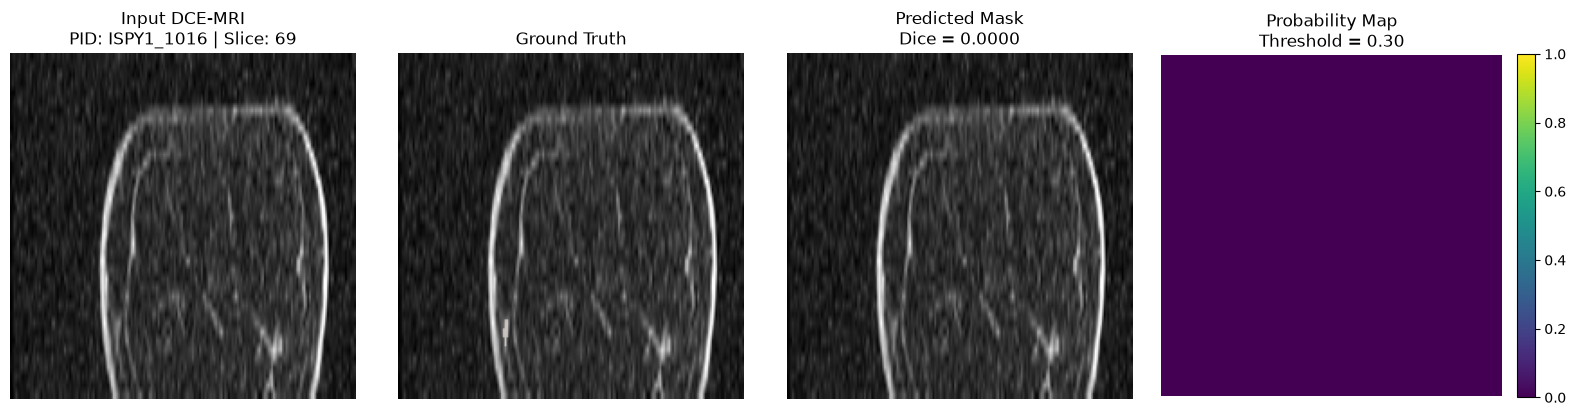

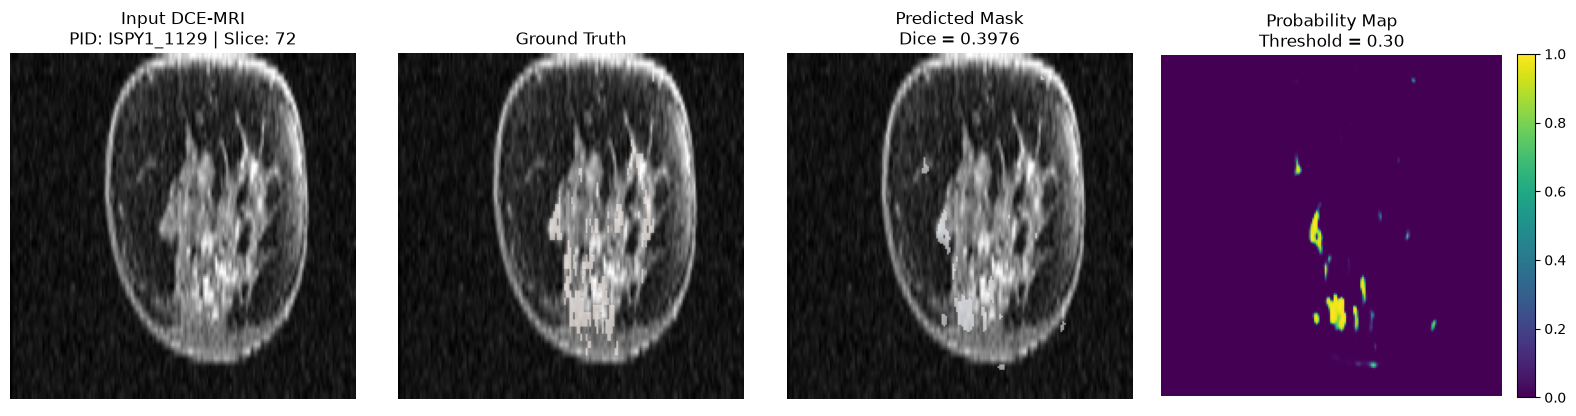

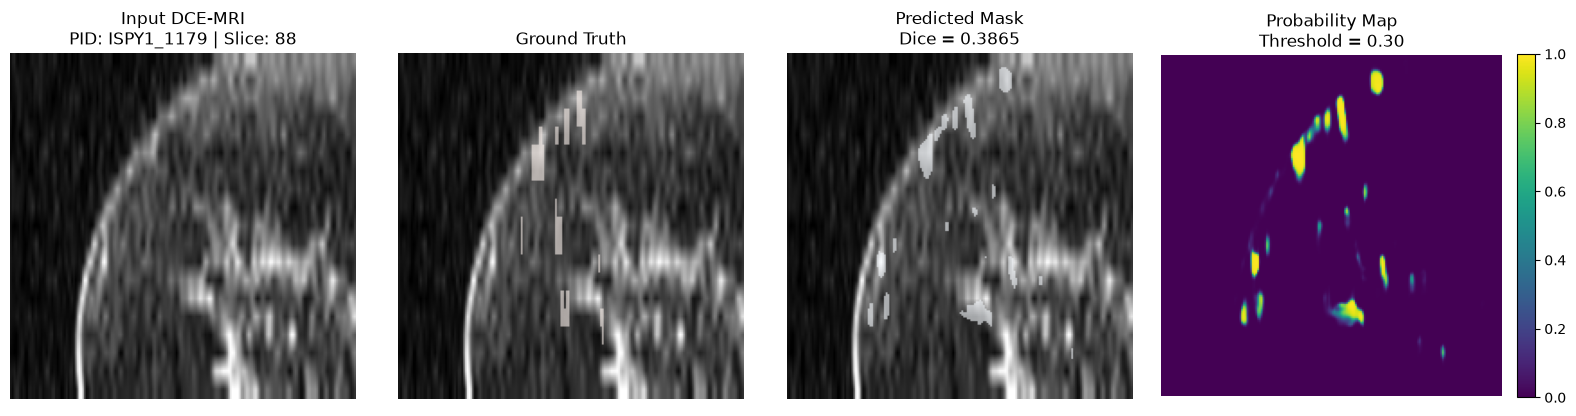

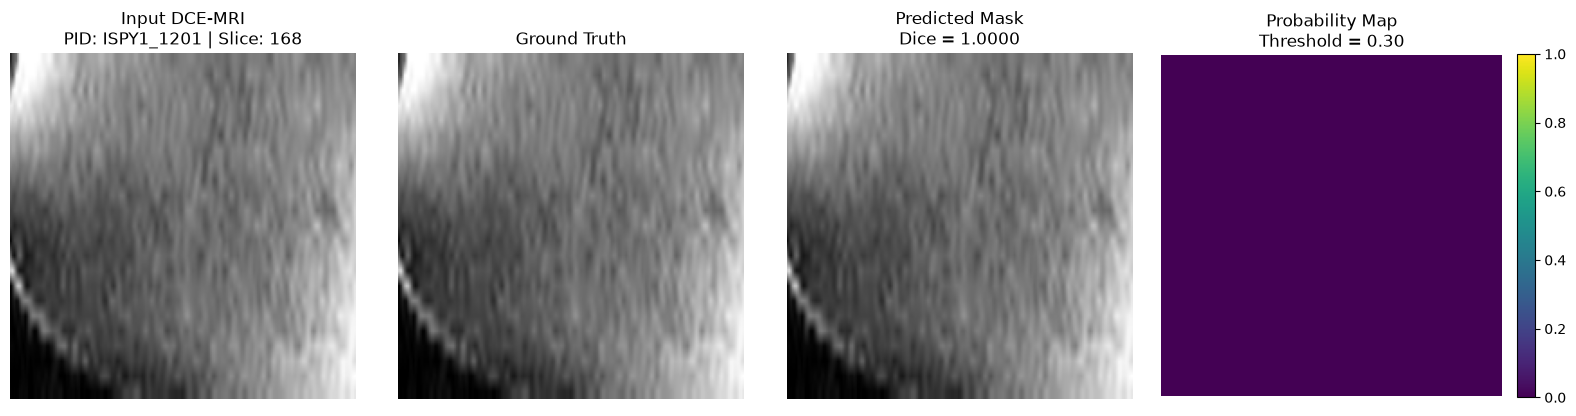

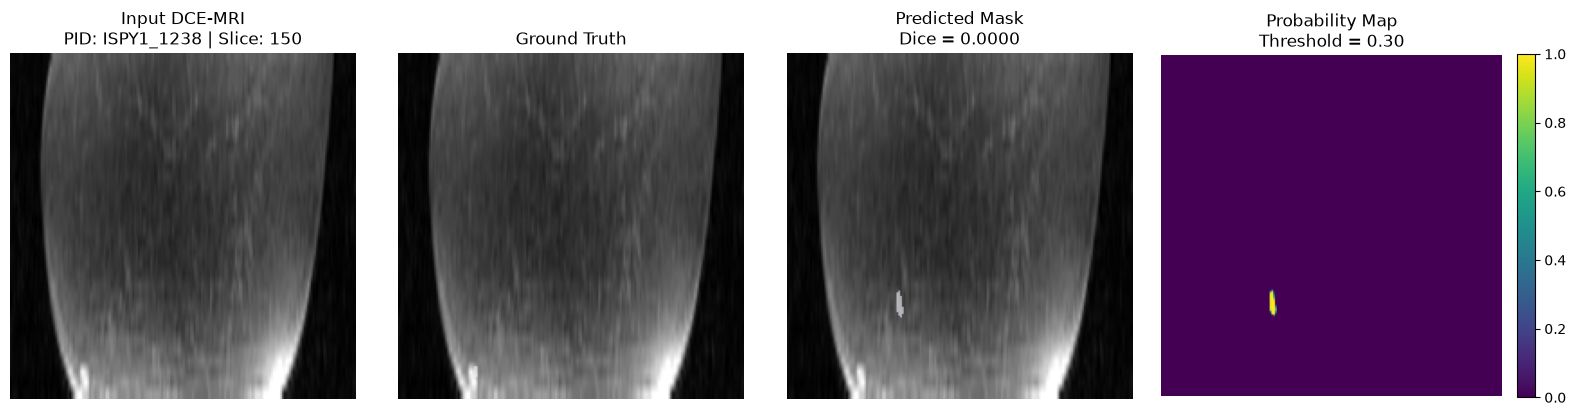

Validation segmentation output completed.
RUN_FINAL_TEST = False
TEST SET WAS NOT USED.


In [4]:
# ============================================================
# STANDALONE SEGMENTATION OUTPUT
# VALIDATION SET ONLY
# NO TRAINING
# NO FINAL TEST
# ============================================================

RUN_FINAL_TEST = False

from pathlib import Path
from functools import lru_cache
import json

import numpy as np
import pandas as pd
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\BreastDCEDL\CGMRNet")

OUTPUT_DIR = PROJECT_ROOT / "outputs_datafirst"

SEGMENTATION_CKPT = (
    PROJECT_ROOT
    / "checkpoints_datafirst"
    / "best_segmentation.pt"
)

SEGMENTATION_INDEX = (
    OUTPUT_DIR
    / "segmentation_index.csv"
)

THRESHOLD_FILE = (
    OUTPUT_DIR
    / "segmentation_threshold.json"
)


print("Checkpoint :", SEGMENTATION_CKPT)
print("Seg index  :", SEGMENTATION_INDEX)

assert SEGMENTATION_CKPT.is_file(), (
    f"Checkpoint not found:\n{SEGMENTATION_CKPT}"
)

assert SEGMENTATION_INDEX.is_file(), (
    f"Segmentation index not found:\n{SEGMENTATION_INDEX}"
)


# ============================================================
# 2. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PREPROCESSING CONFIG
# SAME AS TRAINING NOTEBOOK
# ============================================================

N_CHANNELS = 5
SEG_IMAGE_SIZE = 192

CLIP_LOW = 0.5
CLIP_HIGH = 99.5

ENHANCEMENT_FLOOR_FRACTION = 0.05

OUTPUT_CLIP_Z = 8.0


# ============================================================
# 4. NIFTI FUNCTIONS
# ============================================================

@lru_cache(maxsize=128)
def open_nifti(path_text):

    return nib.load(
        path_text,
        mmap=True
    )


def load_slice(
    path,
    z,
    frame=None
):

    image = open_nifti(
        str(path)
    )

    shape = image.shape

    z = int(z)

    if not 0 <= z < shape[2]:

        raise IndexError(
            f"z={z} outside {shape}"
        )


    if len(shape) == 4:

        if (
            frame is None
            or pd.isna(frame)
        ):

            raise ValueError(
                f"Frame required for {path}"
            )

        array = np.asarray(
            image.dataobj[
                :,
                :,
                z,
                int(frame)
            ]
        )

    elif len(shape) == 3:

        array = np.asarray(
            image.dataobj[
                :,
                :,
                z
            ]
        )

    else:

        raise ValueError(
            f"Unsupported shape: {shape}"
        )


    return np.nan_to_num(
        array.astype(
            np.float32
        ),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


# ============================================================
# 5. PREPROCESSING
# ============================================================

def tissue_mask(*phases):

    return np.logical_or.reduce(
        [
            np.isfinite(x)
            &
            (np.abs(x) > 1e-6)

            for x in phases
        ]
    )


def robust_clip(
    array,
    mask
):

    values = array[mask]

    if values.size < 16:
        return array


    low, high = np.percentile(
        values,
        [
            CLIP_LOW,
            CLIP_HIGH
        ]
    )


    if (
        not np.isfinite(
            [low, high]
        ).all()
        or high <= low
    ):

        return array


    return np.clip(
        array,
        low,
        high
    )


def foreground_zscore(
    array,
    mask
):

    array = robust_clip(
        array,
        mask
    )

    values = array[mask]

    output = np.zeros_like(
        array,
        dtype=np.float32
    )


    if values.size < 16:
        return output


    mean = float(
        values.mean()
    )

    std = float(
        values.std()
    )


    if (
        not np.isfinite(std)
        or std < 1e-6
    ):

        return output


    output[mask] = (
        array[mask] - mean
    ) / std


    return np.clip(
        output,
        -OUTPUT_CLIP_Z,
        OUTPUT_CLIP_Z
    ).astype(
        np.float32
    )


def relative_enhancement(
    post,
    pre,
    mask
):

    baseline = np.abs(
        pre[mask]
    )


    scale = (
        float(
            np.median(
                baseline
            )
        )
        if baseline.size
        else 1.0
    )


    floor = max(
        scale
        * ENHANCEMENT_FLOOR_FRACTION,
        1e-3
    )


    output = np.zeros_like(
        pre,
        dtype=np.float32
    )


    output[mask] = (

        post[mask]
        -
        pre[mask]

    ) / np.maximum(

        np.abs(
            pre[mask]
        ),

        floor
    )


    return foreground_zscore(
        output,
        mask
    )


def preprocess_phases(
    pre,
    early,
    late
):

    pre, early, late = [

        np.nan_to_num(
            np.asarray(
                x,
                dtype=np.float32
            ),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        for x in (
            pre,
            early,
            late
        )
    ]


    if not (
        pre.shape
        ==
        early.shape
        ==
        late.shape
    ):

        raise ValueError(
            "DCE phase shapes differ."
        )


    mask = tissue_mask(
        pre,
        early,
        late
    )


    if int(
        mask.sum()
    ) < 16:

        return np.zeros(
            (
                N_CHANNELS,
                *pre.shape
            ),
            dtype=np.float32
        )


    channels = np.stack(
        [

            foreground_zscore(
                pre,
                mask
            ),

            foreground_zscore(
                early,
                mask
            ),

            foreground_zscore(
                late,
                mask
            ),

            relative_enhancement(
                early,
                pre,
                mask
            ),

            relative_enhancement(
                late,
                pre,
                mask
            )
        ]
    ).astype(
        np.float32
    )


    channels[:, ~mask] = 0.0


    return np.ascontiguousarray(
        channels
    )


def resize_channels(
    channels,
    size=192
):

    tensor = torch.from_numpy(

        np.ascontiguousarray(
            channels,
            dtype=np.float32
        )

    ).unsqueeze(0)


    resized = F.interpolate(

        tensor,

        size=(
            int(size),
            int(size)
        ),

        mode="bilinear",

        align_corners=False
    )


    return (
        resized[0]
        .numpy()
        .astype(
            np.float32
        )
    )


def resize_mask(
    mask,
    size=192
):

    tensor = torch.from_numpy(

        np.ascontiguousarray(
            mask,
            dtype=np.float32
        )

    )[None, None]


    resized = F.interpolate(

        tensor,

        size=(
            int(size),
            int(size)
        ),

        mode="nearest"
    )


    return (
        resized[
            0,
            0
        ]
        .numpy()
        >= 0.5
    ).astype(
        np.float32
    )


# ============================================================
# 6. SEGMENTATION MODEL
# EXACT LIGHT U-NET USED DURING TRAINING
# ============================================================

class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        groups = min(
            8,
            out_channels
        )


        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.SiLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.SiLU(
                inplace=True
            )
        )


    def forward(
        self,
        x
    ):

        return self.block(x)


class LightUNet(nn.Module):

    def __init__(
        self,
        in_channels=5,
        base=16
    ):

        super().__init__()


        self.e1 = ConvBlock(
            in_channels,
            base
        )

        self.e2 = ConvBlock(
            base,
            base * 2
        )

        self.e3 = ConvBlock(
            base * 2,
            base * 4
        )

        self.bridge = ConvBlock(
            base * 4,
            base * 8
        )

        self.d3 = ConvBlock(
            base * 8 + base * 4,
            base * 4
        )

        self.d2 = ConvBlock(
            base * 4 + base * 2,
            base * 2
        )

        self.d1 = ConvBlock(
            base * 2 + base,
            base
        )

        self.out = nn.Conv2d(
            base,
            1,
            1
        )


    def forward(
        self,
        x
    ):

        e1 = self.e1(x)

        e2 = self.e2(
            F.max_pool2d(
                e1,
                2
            )
        )

        e3 = self.e3(
            F.max_pool2d(
                e2,
                2
            )
        )

        bridge = self.bridge(
            F.max_pool2d(
                e3,
                2
            )
        )


        d3 = self.d3(

            torch.cat(
                [

                    F.interpolate(
                        bridge,
                        e3.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    ),

                    e3
                ],

                dim=1
            )
        )


        d2 = self.d2(

            torch.cat(
                [

                    F.interpolate(
                        d3,
                        e2.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    ),

                    e2
                ],

                dim=1
            )
        )


        d1 = self.d1(

            torch.cat(
                [

                    F.interpolate(
                        d2,
                        e1.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    ),

                    e1
                ],

                dim=1
            )
        )


        return self.out(
            d1
        )


# ============================================================
# 7. LOAD BEST TRAINED MODEL
# ============================================================

segmentation_model = LightUNet(
    in_channels=5
).to(
    DEVICE
)


checkpoint = torch.load(
    SEGMENTATION_CKPT,
    map_location=DEVICE,
    weights_only=False
)


segmentation_model.load_state_dict(
    checkpoint[
        "model_state"
    ]
)


segmentation_model.eval()


print(
    "Best checkpoint loaded."
)

print(
    "Best epoch:",
    checkpoint.get(
        "epoch"
    )
)

print(
    "Best validation Dice:",
    checkpoint.get(
        "val_patient_dice"
    )
)


# ============================================================
# 8. VALIDATION THRESHOLD
# ============================================================

if THRESHOLD_FILE.is_file():

    with open(
        THRESHOLD_FILE,
        "r",
        encoding="utf-8"
    ) as f:

        threshold_data = json.load(
            f
        )


    SEG_THRESHOLD = float(
        threshold_data[
            "threshold"
        ]
    )

else:

    # Validation-selected threshold from completed training
    SEG_THRESHOLD = 0.30


print(
    "Segmentation threshold:",
    SEG_THRESHOLD
)


# ============================================================
# 9. LOAD VALIDATION INDEX ONLY
# TEST DATA IS NEVER ACCESSED
# ============================================================

seg_index = pd.read_csv(
    SEGMENTATION_INDEX
)


val_frame = seg_index[
    seg_index["_split"]
    ==
    "val"
].copy()


print(
    "Validation slices:",
    len(val_frame)
)


# Prefer tumour-containing slices for visualization
positive_val = val_frame[
    val_frame[
        "tumour_present"
    ]
    ==
    1
].copy()


if len(
    positive_val
) >= 5:

    # Get slices distributed across validation set
    positions = np.linspace(
        0,
        len(positive_val) - 1,
        5,
        dtype=int
    )

    display_rows = positive_val.iloc[
        positions
    ]

else:

    display_rows = val_frame.head(
        5
    )


# ============================================================
# 10. SEGMENTATION OUTPUT
# ============================================================

@torch.inference_mode()
def predict_validation_slice(
    row
):

    z = int(
        row[
            "slice_idx"
        ]
    )


    pre = load_slice(

        row[
            "pre_path"
        ],

        z,

        row.get(
            "pre_frame"
        )
    )


    early = load_slice(

        row[
            "early_path"
        ],

        z,

        row.get(
            "early_frame"
        )
    )


    late = load_slice(

        row[
            "late_path"
        ],

        z,

        row.get(
            "late_frame"
        )
    )


    gt_original = (
        load_slice(
            row[
                "mask_path"
            ],
            z
        )
        >
        0
    )


    image = resize_channels(

        preprocess_phases(
            pre,
            early,
            late
        ),

        SEG_IMAGE_SIZE
    )


    gt_mask = resize_mask(

        gt_original,

        SEG_IMAGE_SIZE
    )


    input_tensor = torch.from_numpy(
        image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )


    if USE_AMP:

        with torch.amp.autocast(
            "cuda",
            dtype=torch.float16
        ):

            logits = segmentation_model(
                input_tensor
            )

    else:

        logits = segmentation_model(
            input_tensor
        )


    probability = torch.sigmoid(
        logits
    )[0, 0].float().cpu().numpy()


    prediction = (
        probability
        >=
        SEG_THRESHOLD
    ).astype(
        np.float32
    )


    gt_binary = (
        gt_mask
        >=
        0.5
    )


    pred_binary = (
        prediction
        >=
        0.5
    )


    intersection = np.logical_and(
        gt_binary,
        pred_binary
    ).sum()


    denominator = (
        gt_binary.sum()
        +
        pred_binary.sum()
    )


    dice = (

        1.0

        if denominator == 0

        else

        (
            2.0
            *
            intersection
            /
            denominator
        )
    )


    return (
        image,
        gt_mask,
        prediction,
        probability,
        float(dice)
    )


# ============================================================
# 11. DISPLAY 5 VALIDATION SEGMENTATION RESULTS
# ============================================================

for _, row in display_rows.iterrows():

    (
        image,
        gt_mask,
        pred_mask,
        probability,
        dice
    ) = predict_validation_slice(
        row
    )


    gt_overlay = np.ma.masked_where(
        gt_mask < 0.5,
        gt_mask
    )


    pred_overlay = np.ma.masked_where(
        pred_mask < 0.5,
        pred_mask
    )


    fig, axes = plt.subplots(
        1,
        4,
        figsize=(
            16,
            4
        )
    )


    # ----------------------------------------
    # Input MRI
    # ----------------------------------------

    axes[0].imshow(
        image[0],
        cmap="gray"
    )

    axes[0].set_title(
        f"Input DCE-MRI\n"
        f"PID: {row['pid']} | "
        f"Slice: {int(row['slice_idx'])}"
    )

    axes[0].axis(
        "off"
    )


    # ----------------------------------------
    # Ground truth
    # ----------------------------------------

    axes[1].imshow(
        image[0],
        cmap="gray"
    )

    axes[1].imshow(
        gt_overlay,
        cmap="Reds",
        alpha=0.60
    )

    axes[1].set_title(
        "Ground Truth"
    )

    axes[1].axis(
        "off"
    )


    # ----------------------------------------
    # Predicted segmentation
    # ----------------------------------------

    axes[2].imshow(
        image[0],
        cmap="gray"
    )

    axes[2].imshow(
        pred_overlay,
        cmap="Blues",
        alpha=0.60
    )

    axes[2].set_title(
        f"Predicted Mask\n"
        f"Dice = {dice:.4f}"
    )

    axes[2].axis(
        "off"
    )


    # ----------------------------------------
    # Probability map
    # ----------------------------------------

    probability_plot = axes[3].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    axes[3].set_title(
        f"Probability Map\n"
        f"Threshold = {SEG_THRESHOLD:.2f}"
    )

    axes[3].axis(
        "off"
    )


    fig.colorbar(
        probability_plot,
        ax=axes[3],
        fraction=0.046,
        pad=0.04
    )


    plt.tight_layout()
    plt.show()
    plt.close(fig)


# ============================================================
# FINAL STATUS
# ============================================================

print(
    "Validation segmentation output completed."
)

print(
    "RUN_FINAL_TEST =",
    RUN_FINAL_TEST
)

print(
    "TEST SET WAS NOT USED."
)

## Exact execution order

1. Click **Run → Restart Kernel and Run All Cells**.
2. Confirm `START CELL PASSED`, `IMPORT CELL PASSED`, and `CUDA available: True`.
3. Allow the three archives to extract; each archive now has a visible progress bar.
4. Confirm `MANIFEST STAGE PASSED`, nonzero train/validation/test loader counts, and
   `Preprocessing QC PASSED`.
5. Segmentation and classification then run for 30 epochs automatically.
6. After both training-finished messages appear, change only `RUN_FINAL_TEST=False` to
   `RUN_FINAL_TEST=True` and run the final cell once.

If a cell fails, stop there and copy its complete red traceback. Do not continue to later
cells because they depend on variables created by every earlier stage.
